In [1]:
%load_ext autoreload
%autoreload 2

# 1.Imports

In [2]:
import warnings


import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from src.check_data import (
    analyze_associations,
    analyze_categorical_data,
    analyze_data_quality,
    analyze_feature_importance,
    calculate_iv,
    display_cat_counts,
    get_lof_outliers,
    plot_stripplot_comparison,
    plot_target_distribution
)

# 2.Configs

In [4]:
pd.set_option("display.max_columns",None) # Tüm sütunları görelim

In [5]:
warnings.filterwarnings("ignore")

# 3.Constants

In [6]:
TARGET_COL = "Target"

# 4.Read Data

In [7]:
df = pd.read_excel("data/raw/CaseStudyData_2020.xlsx", index_col=0)

In [8]:
BASE_NUMERIC_COLS = df.drop(columns=[TARGET_COL]).select_dtypes(include=['number']).columns.tolist()
BASE_CAT_COLS = df.drop(columns=[TARGET_COL]).select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Sayısal Değişken Sayısı: {len(BASE_NUMERIC_COLS)}")
print(f"Kategorik Değişken Sayısı: {len(BASE_CAT_COLS)}")

Sayısal Değişken Sayısı: 35
Kategorik Değişken Sayısı: 15


In [9]:
df.head()

,Target,Var_1,Var_2,Var_3,Var_4,Var_5,Var_6,Var_7,Var_8,Var_9,Var_10,Var_11,Var_12,Var_13,Var_14,Var_15,Var_16,Var_17,Var_18,Var_19,Var_20,Var_21,Var_22,Var_23,Var_24,Var_25,Var_26,Var_27,Var_28,Var_29,Var_30,Var_31,Var_32,Var_33,Var_34,Var_35,Var_36,Var_37,Var_38,Var_39,Var_40,Var_41,Var_42,Var_43,Var_44,Var_45,Var_46,Var_47,Var_48,Var_49,Var_50
0,0,0,L,Y,1750.0,1,36.0,86,2606,A,888.0,Y,4.0,0,N,Y,0.0,5000.0,523,201,1.0,1104.0,0.0,2700,2350,26.0,33,2350,2350.0,NaN,2350.0,0,0,NaN,1,N,2,N,NaN,562.0,NaN,5.0,NaN,NaN,Y,N,NaN,0,N,N,Y
1,0,0,1,N,1300.0,12,NaN,13,406,R,20.0,NaN,4.0,0,N,Y,0.0,0.0,0,1004,1.0,3.0,0.0,3000,1600,14.0,46,1600,1600.0,500.0,3000.0,1,0,NaN,3,N,0,N,NaN,24.0,NaN,15.0,NaN,NaN,Y,N,NaN,0,N,N,Y
2,0,0,0,N,0.0,0,NaN,274,8337,A,511.0,NaN,0.0,0,Y,N,0.0,5000.0,2572,0,1.0,NaN,1.0,1450,1600,NaN,84,4100,1600.0,NaN,3500.0,0,0,NaN,2,N,1,N,NaN,479.0,NaN,NaN,NaN,NaN,Y,N,NaN,0,N,N,N
3,1,0,L,Y,800.0,3,37.0,6,8,A,0.0,N,45.0,0,N,Y,0.0,0.0,935,176,3.0,5.0,0.0,1600,2030,25.0,108,2030,2030.0,NaN,2030.0,0,0,NaN,0,N,X,N,NaN,0.0,NaN,NaN,NaN,NaN,N,N,NaN,0,N,N,Y
4,0,0,1,N,6250.0,0,NaN,126,3833,A,32.0,NaN,8.0,0,Y,Y,0.0,7450.0,1300,2402,NaN,NaN,5.0,0,0,31.0,197,5000,0.0,1850.0,NaN,2,0,NaN,8,N,1,N,NaN,52.0,NaN,NaN,0.0,NaN,Y,N,NaN,0,N,N,N


Gözlemler:
- İlk gözümüze çarpan ayrıntı: **Target** Oranı yaklaşık **%4.7681**
- **Unbalanced Classification** problemi ile karşı karşıyayız.
- Elimizde kategorik ve sayısal değişkenler var.
- Var_10, Var_23, Var_39 gibi değişkenler aykırı değerler içerebilir.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Target,34584.0,0.047681,0.213094,0.0,0.0,0.0,0.0,1.0
Var_1,34584.0,0.099352,0.424117,0.0,0.0,0.0,0.0,11.0
Var_4,26113.0,1790.202504,3410.280970,0.0,0.0,200.0,2400.0,80000.0
Var_5,34584.0,3.448994,5.224116,0.0,1.0,2.0,4.0,231.0
Var_6,5550.0,31.411532,17.922130,1.0,17.0,31.0,45.0,214.0
Var_7,34584.0,73.428435,68.804426,0.0,13.0,56.0,117.0,350.0
Var_8,34584.0,1983.583998,2096.732056,0.0,32.0,1356.0,3307.0,10657.0
Var_10,34569.0,2418.822384,34151.199903,0.0,0.0,2.0,112.0,4170043.0
Var_12,30552.0,9.882986,11.366188,0.0,2.0,6.0,13.0,61.0
Var_13,34584.0,0.540279,1.321713,0.0,0.0,0.0,1.0,45.0


# 5.Explore Data

## 5.1 Null And Zero Check

Gözlemler:
- Bazı değişkenler NULL oranı çok yüksek.
- **Target** değişkeninde eksik değer yok, bu iyi haber.
- **Var_6, Var_11, Var_12** değişkenleri hedef değişken bazında NULL oranlarında farklılaşıyorlar. Fakat bu ayrışma çok yüksek değil.

In [11]:
analyze_data_quality(df, TARGET_COL)

,Dtype,Null_Gen (%),Null_T0 (%),Null_T1 (%),Zero_Gen (%),Zero_T0 (%),Zero_T1 (%)
Var_38,str,99.71%,99.74%,99.09%,0.00%,0.00%,0.00%
Var_40,float64,99.47%,99.46%,99.76%,0.47%,0.48%,0.18%
Var_43,float64,99.47%,99.46%,99.76%,0.47%,0.49%,0.18%
Var_33,float64,96.62%,96.54%,98.18%,2.79%,2.87%,1.33%
Var_46,float64,95.98%,95.88%,97.88%,2.97%,3.06%,1.09%
Var_42,float64,91.42%,91.11%,97.57%,6.15%,6.41%,0.97%
Var_6,float64,83.95%,84.62%,70.71%,0.00%,0.00%,0.00%
Var_11,str,81.96%,82.64%,68.34%,0.00%,0.00%,0.00%
Var_41,float64,71.29%,71.00%,77.08%,0.06%,0.05%,0.18%
Var_29,float64,66.72%,66.30%,75.08%,0.55%,0.57%,0.24%


## 5.2 Cardinality Check

Gözlemler:

- **Var_38** değişkenini silebiliriz çünkü varyansı = 0. Bize hiçbir bilgi vermeyecektir.

In [12]:
analyze_categorical_data(df)

--- Kategorik Değişken Özeti (15 Sütun) ---


,Column Name,Dtype,Unique Count,Null Count,Null Ratio (%),Mode (Most Frequent)
7,Var_36,object,11,0,0.00%,1
0,Var_2,object,9,0,0.00%,0
2,Var_9,str,3,9048,26.16%,A
3,Var_11,str,2,28346,81.96%,N
4,Var_14,str,2,2052,5.93%,N
5,Var_15,str,2,0,0.00%,Y
1,Var_3,str,2,0,0.00%,N
6,Var_35,str,2,0,0.00%,N
8,Var_37,str,2,0,0.00%,N
10,Var_44,str,2,0,0.00%,N


In [13]:
BASE_CAT_COLS.remove("Var_38")
df.drop(columns=["Var_38"], inplace=True)

- Yalnızca iki değer bulundurduğu ve hiç NULL bulundurmadıkları için **Var_3, Var_15, Var_35, Var_37, Var_44, Var_45, Var_48, Var_49 ** değişkenlerine **One Hot Encoding** uygulayacağız.

- Var_9 değişkeni sadece 3 farklı değişkenden oluştuğu için ona da **OHE** uygulayacağız. Fakat NULL değerleri **"Missing"** ile dolduracağız.

- **Var_9, Var_11, Var_14, Var_50, Var_38** değişkenlerini **"Missing"** ile doldurup **OHE** uygulayacağız.

- **Var_36, Var_2** değişkenlerini de **OHE** uygulayacağız.

- **Dummy Variable Trap'ten** kurtulmak için **drop='First'* argümanını kullanacağız.


In [14]:
display_cat_counts(df,BASE_CAT_COLS)

,count
Var_2,
0,14257
1,11996
L,5590
2,1610
8,648
3,375
4,96
6,6
U,6


In [15]:
df[BASE_CAT_COLS] = df[BASE_CAT_COLS].fillna("MISSING") # Kategorik tüm sütunlardaki eksik değerleri "NULL" ile dolduralım.

In [16]:
df[BASE_CAT_COLS] = df[BASE_CAT_COLS].astype('category') # Bellek verimliliği için veri tipi değişikliği

## 5.3 Duplicated Check

In [17]:
print(df.duplicated().sum()) # yalnızca iki adet satır birbirinin aynısı

2


In [18]:
df[df.duplicated()]

,Target,Var_1,Var_2,Var_3,Var_4,Var_5,Var_6,Var_7,Var_8,Var_9,Var_10,Var_11,Var_12,Var_13,Var_14,Var_15,Var_16,Var_17,Var_18,Var_19,Var_20,Var_21,Var_22,Var_23,Var_24,Var_25,Var_26,Var_27,Var_28,Var_29,Var_30,Var_31,Var_32,Var_33,Var_34,Var_35,Var_36,Var_37,Var_39,Var_40,Var_41,Var_42,Var_43,Var_44,Var_45,Var_46,Var_47,Var_48,Var_49,Var_50
21880,0,0,0,N,NaN,0,NaN,0,0,MISSING,0.0,MISSING,NaN,0,N,N,0.0,NaN,0,0,NaN,NaN,NaN,0,0,NaN,0,3000,0.0,NaN,NaN,1,0,NaN,0,N,0,N,0.0,NaN,NaN,NaN,NaN,N,N,NaN,0,N,N,MISSING
23364,0,0,0,N,NaN,0,NaN,0,0,MISSING,0.0,MISSING,5.0,0,N,N,0.0,NaN,0,0,NaN,NaN,NaN,0,0,NaN,0,2000,0.0,NaN,NaN,0,0,NaN,1,N,0,N,0.0,NaN,NaN,NaN,NaN,N,N,NaN,0,N,N,MISSING


In [19]:
# birini silelim
df = df.drop(21880).reset_index(drop=True)

## 5.4 Target Distrubition

Target Oranı **%4.77** olduğundan ve Target=1'leri tahmin etmek daha kritik olacağından PR_AUC metriği bizim için kıymetli olacaktır.

Dengelenmemiş veri setlerinde AUC bizi yanıltır!

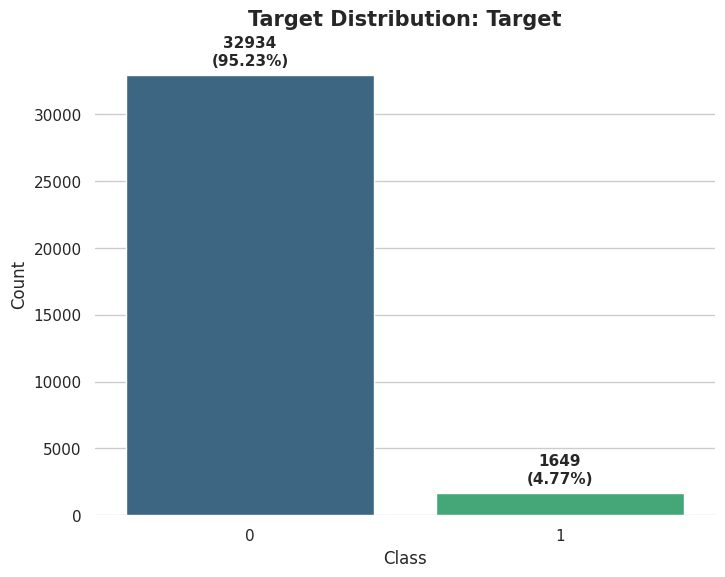

In [20]:
plot_target_distribution(df, TARGET_COL)

## 5.5 Univariate Analysis

Bulgular:

**Var_47** ve **Var_1**'i silebiliriz. Değerlerinin +%90'dan fazlası 0'dan oluşuyor.

In [21]:
#summary = perform_univariate_analysis(df, BASE_NUMERIC_COLS, BASE_CAT_COLS, TARGET_COL)

In [22]:
drop_cols = ["Var_47","Var_1"]
df.drop(columns=drop_cols, inplace=True)
BASE_NUMERIC_COLS = [col for col in BASE_NUMERIC_COLS if col not in drop_cols]

## 5.6 Check Multicollinearity, Variance Inflation Factor

VIF (Variance Inflation Factor): Modelindeki bir feature, diğer feature'ların bir kombinasyonu ile açıklanabiliyorsa (multicollinearity), bu durum XGBoost/LightGBM gibi modellerde feature importance değerlerinin "rastgele" dağılmasına yol açar. 

Gözlemler:

- **Var_24** ve **Var_28** neredeyse birbirinin aynısı!
- **Var_39** ve **Var_10** değşikenleri de birbirine çok benzerler!
- **Var_24** ve **Var_27** değşikenleri de birbirine çok benzerler!
Bu değişkenleri elememiz gerekecek.

- **Var_28**'in NULL oranı **%2.22** iken **Var_24**'ün NULL oranı **%0**. Bu yüzden **Var_24**'ü tutacağız.

- **Var_39** ve **Var_10** değişkenlerinin ikisinin de NULL Oranı **%0**. Bu yüzden Target ile yüksek korelasyona sahip ve Information Value (IF) yüksek olanı tutacağız yani **Var_10**'u tutacağız.

- **Var_24** ve **Var_27** değişkenlerinin ikisinin de NULL Oranı **%0**. Bu yüzden Target ile yüksek korelasyona sahip olanı tutacağız yani **Var_24**'u tutacağız.

In [23]:
analyze_feature_importance(df, ["Var_24","Var_28","Var_39","Var_10","Var_27","Var_43","Var_40","Var_7","Var_8"], TARGET_COL)

,Feature,Spearman_Corr,IV,Predictive_Power
7,Var_7,-0.089156,0.214599,Medium
8,Var_8,-0.079015,0.214036,Medium
3,Var_10,-0.070674,0.147996,Medium
2,Var_39,-0.067967,0.125795,Medium
6,Var_40,0.060454,0.040756,Weak
0,Var_24,-0.000814,0.023402,Weak
4,Var_27,-0.017236,0.023163,Weak
1,Var_28,-0.003049,0.022060,Weak
5,Var_43,0.068866,0.000000,Useless


--- Numeric-Numeric Association (Spearman) ---


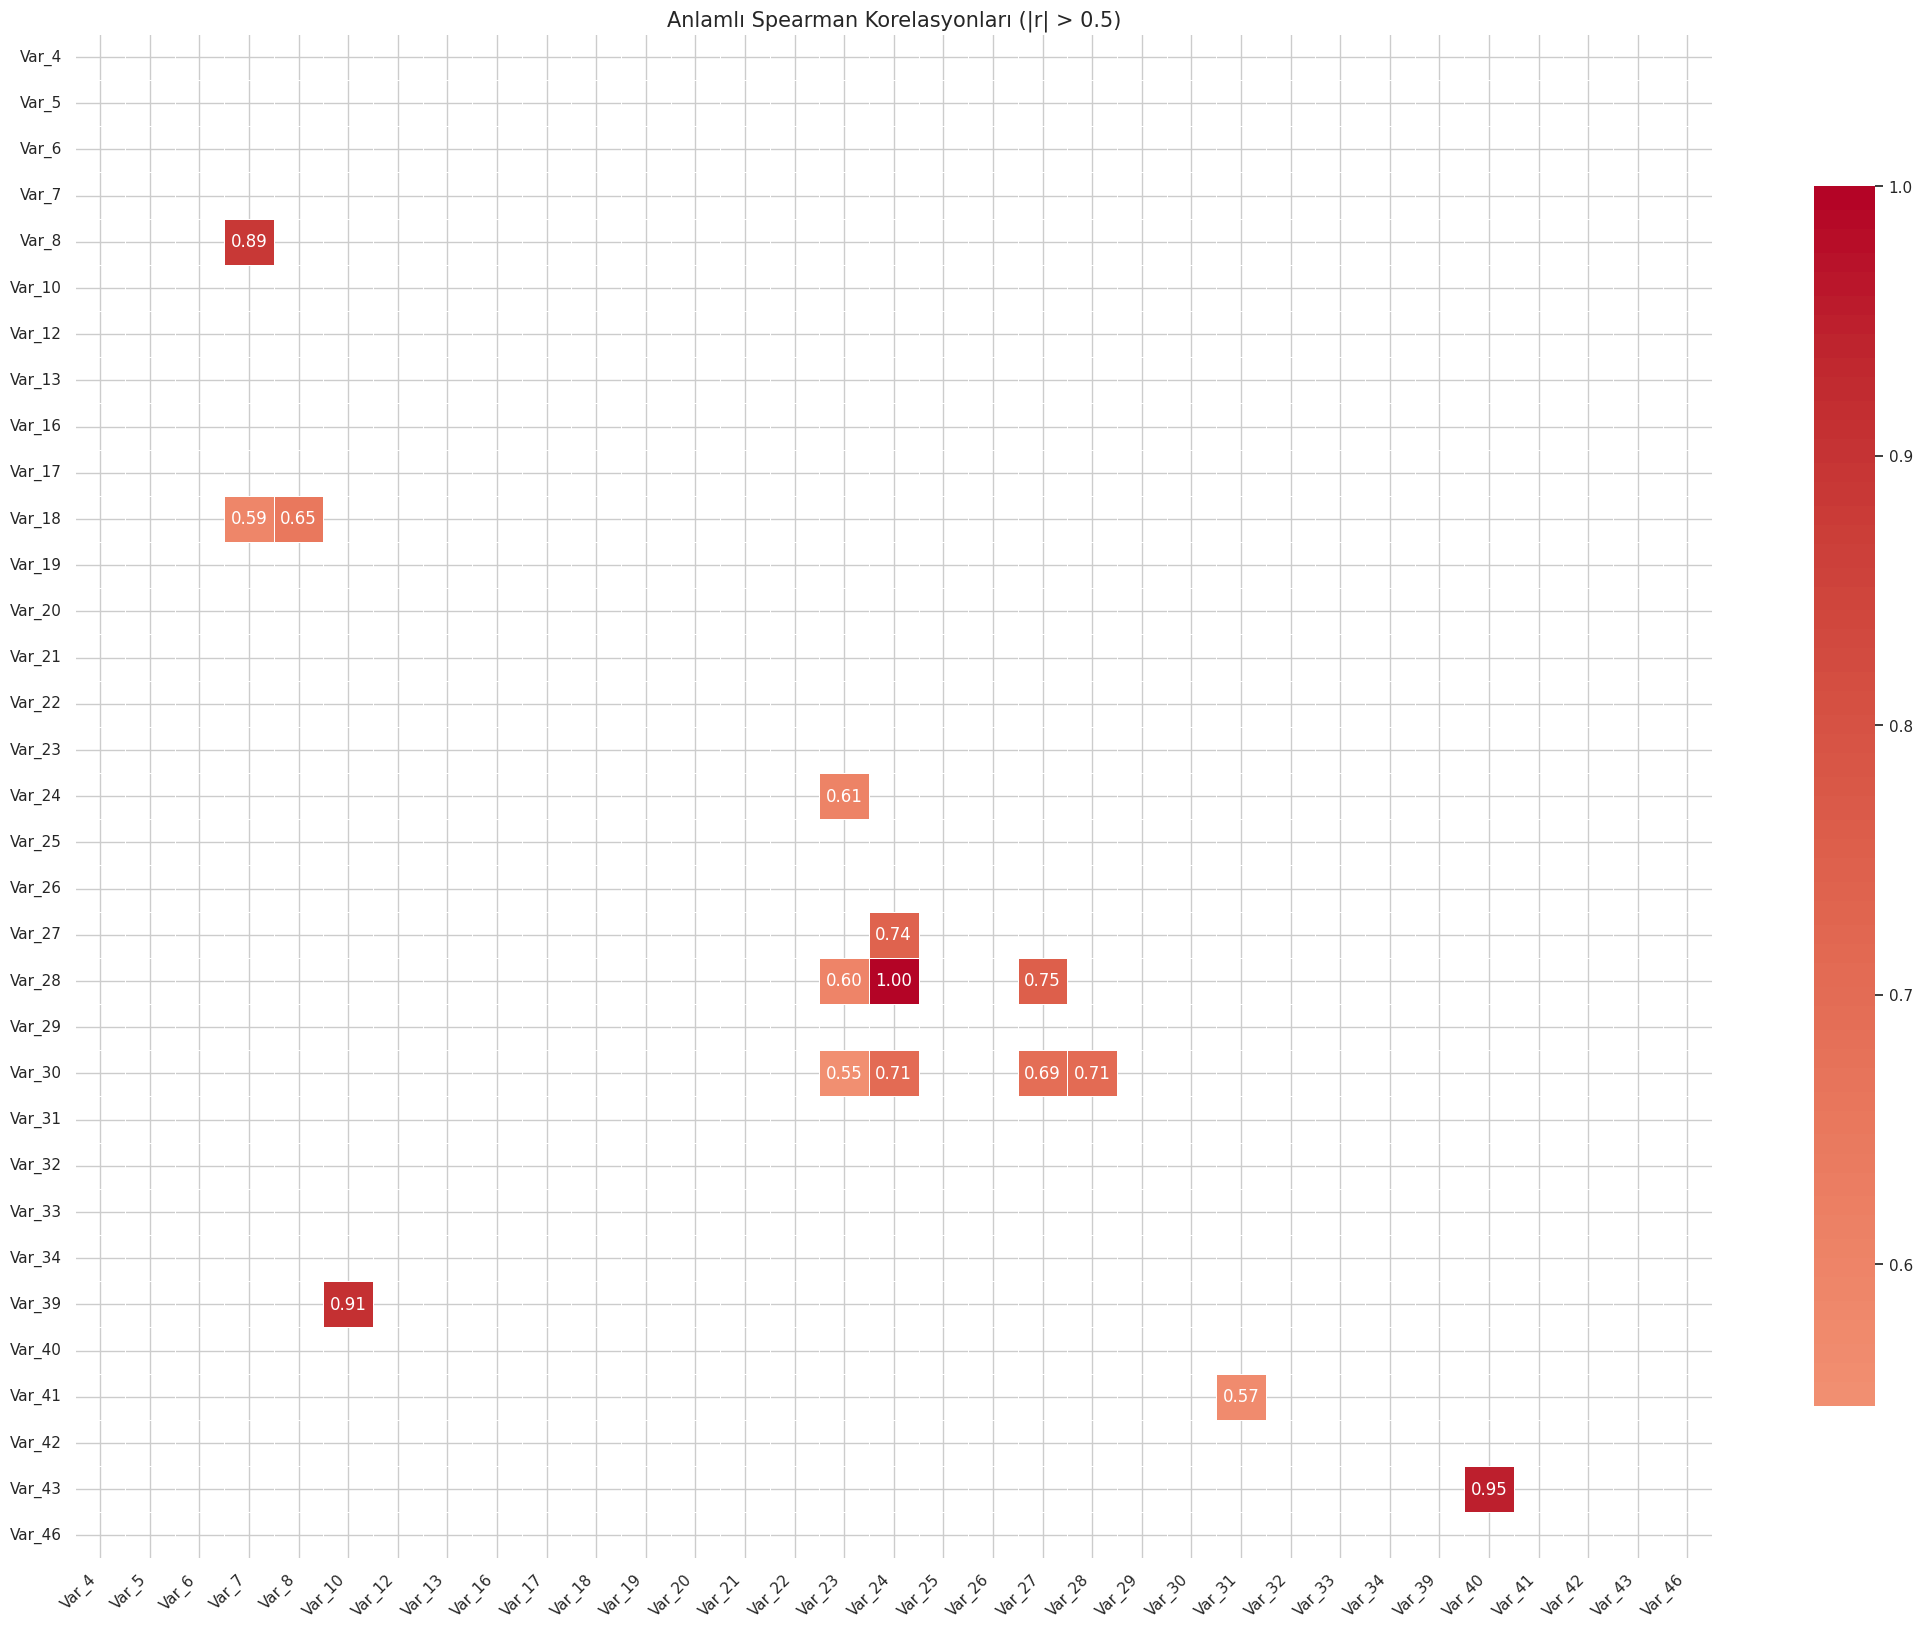


--- Multicollinearity Check (VIF) ---
(!) Uyarı: Yüksek Multicollinearity tespit edildi:
   Feature         VIF
16  Var_24  872.165813
20  Var_28  857.834225
19  Var_27   37.520381
27  Var_39   31.970774
5   Var_10   31.936874
28  Var_40    8.078922
31  Var_43    8.061386
4    Var_8    7.494881
3    Var_7    7.455678


In [24]:
analyze_associations(df, BASE_NUMERIC_COLS, BASE_CAT_COLS, TARGET_COL)

In [25]:
cols_to_drop = ["Var_28", "Var_39", "Var_27", "Var_43", "Var_8"]

df.drop(columns=cols_to_drop, inplace=True)

BASE_NUMERIC_COLS = [col for col in BASE_NUMERIC_COLS if col not in cols_to_drop]

--- Numeric-Numeric Association (Spearman) ---


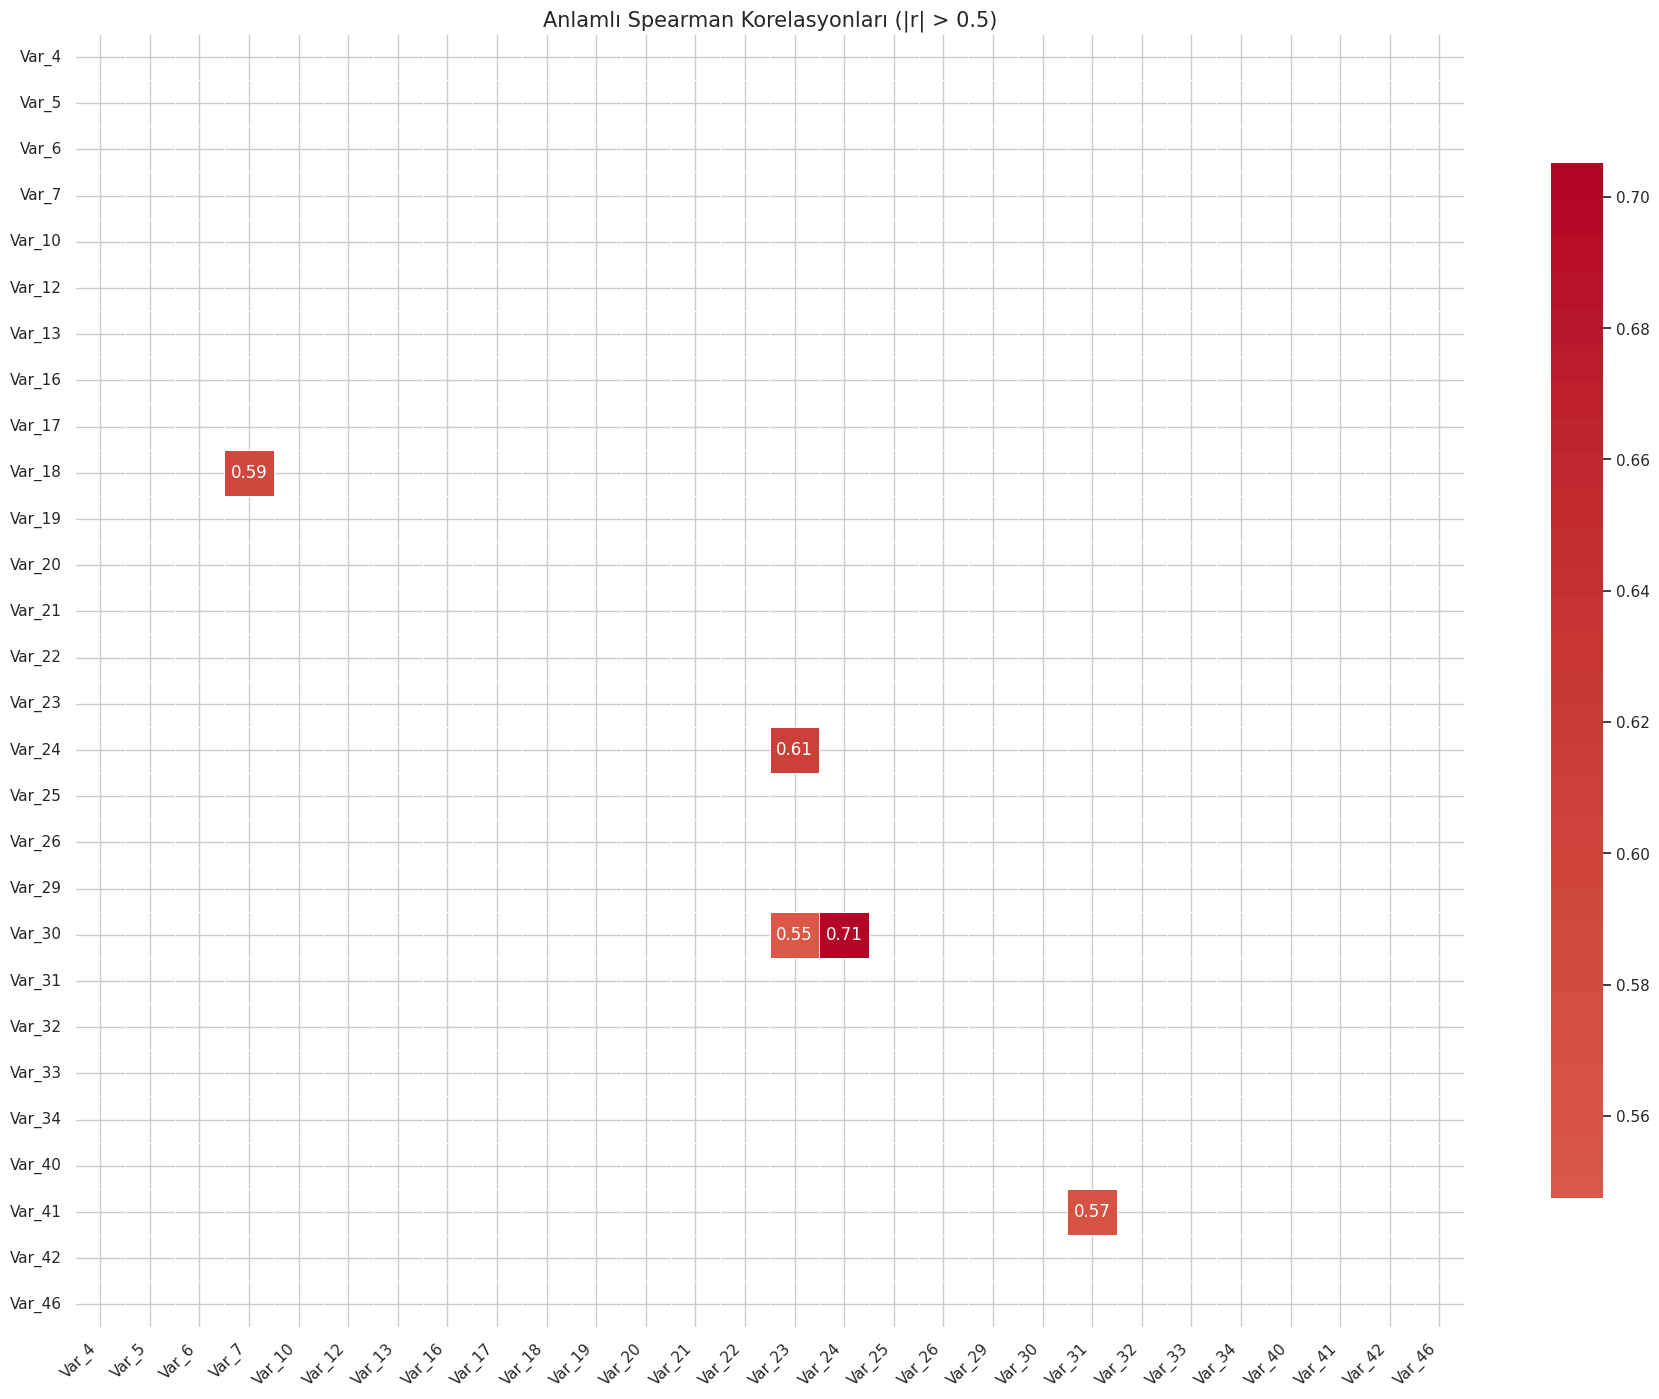


--- Multicollinearity Check (VIF) ---
Kritik seviyede multicollinearity bulunamadı.


In [26]:
analyze_associations(df, BASE_NUMERIC_COLS, BASE_CAT_COLS, TARGET_COL)

## 5.7 Correlation and Information Value With Target

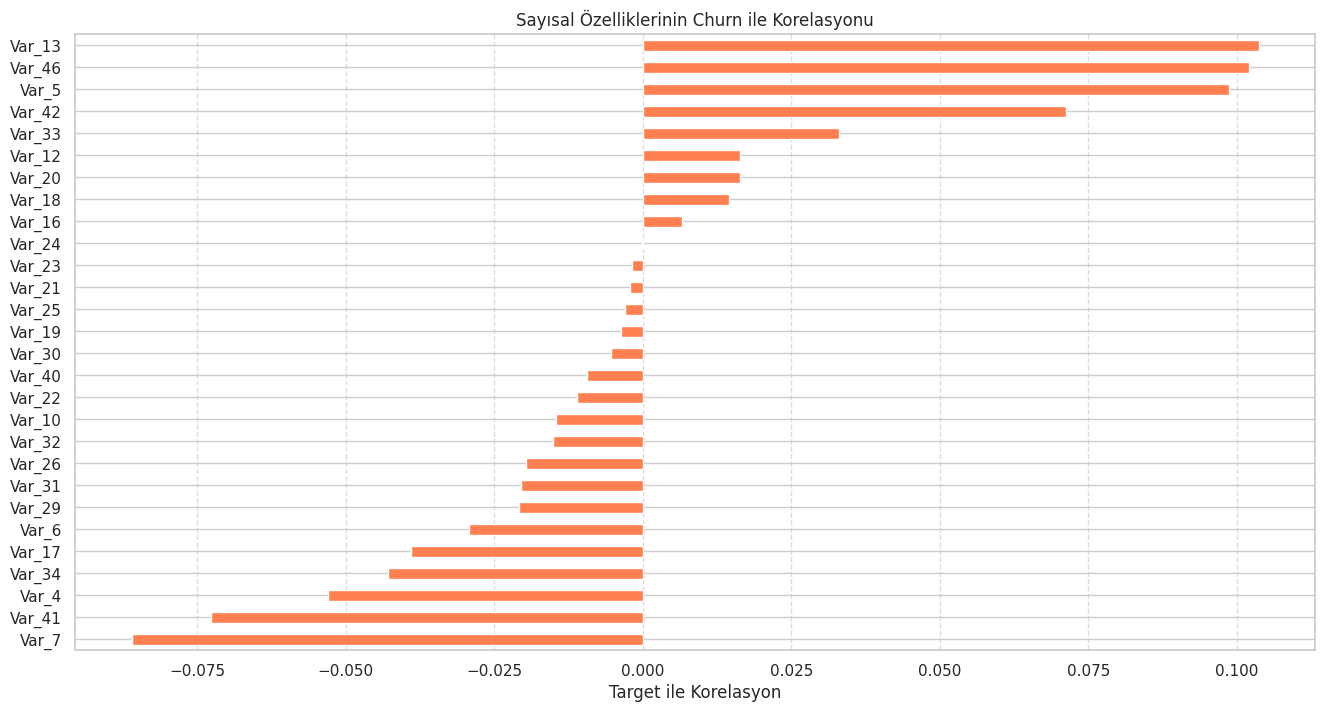

In [27]:
corr_with_churn = df[BASE_NUMERIC_COLS+[TARGET_COL]].corr()[TARGET_COL].iloc[:-1].sort_values()

# Çubuk grafiği
plt.figure(figsize=(16,8))
corr_with_churn.plot(kind='barh', color='coral')
plt.xlabel("Target ile Korelasyon")
plt.title("Sayısal Özelliklerinin Churn ile Korelasyonu")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Feature       IV Null_Ratio_Pct
 Var_42 0.671797         91.42%
 Var_40 0.596802         99.47%
 Var_33 0.564092         96.62%
 Var_46 0.268294         95.98%
  Var_5 0.263116          0.00%
 Var_41 0.223496         71.29%
  Var_7 0.214367          0.00%
  Var_4 0.160484         24.49%
 Var_13 0.157501          0.00%
 Var_10 0.147811          0.04%
 Var_17 0.097233         23.78%
 Var_34 0.093780          0.00%
 Var_29 0.071012         66.71%
 Var_25 0.058549         28.01%
 Var_12 0.041461         11.66%
  Var_6 0.036267         83.95%
 Var_30 0.029065         32.92%
 Var_20 0.029057         15.45%
 Var_24 0.023379          0.00%
 Var_18 0.021296          0.00%
 Var_19 0.020360          0.00%
 Var_23 0.012083          0.00%
 Var_22 0.010670         15.11%
 Var_31 0.009415          0.00%
 Var_21 0.009236         42.26%
 Var_26 0.009160          0.00%
 Var_16 0.000000         46.95%
 Var_32 0.000000          0.00%


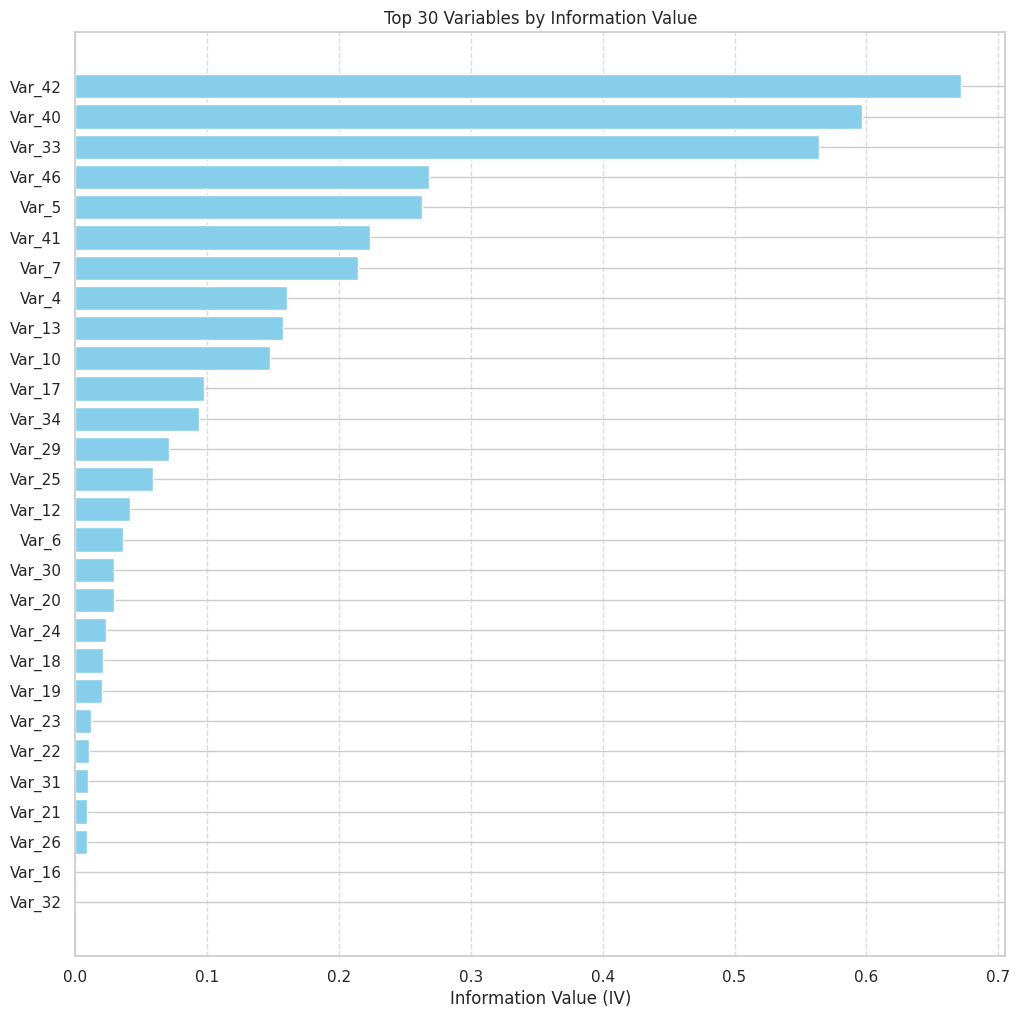

In [28]:
# Calculate IV for all columns (except Target)
iv_values = []
null_ratios = []

for feature in BASE_NUMERIC_COLS:
    iv = calculate_iv(df, feature, TARGET_COL)
    null_ratio = df[feature].isnull().mean()
    iv_values.append(iv)
    null_ratios.append(null_ratio)

# Create results dataframe
results_df = pd.DataFrame({
    'Feature': BASE_NUMERIC_COLS,
    'IV': iv_values,
    'Null_Ratio': null_ratios
}).sort_values(by='IV', ascending=False)

# Formatting
results_df['Null_Ratio_Pct'] = results_df['Null_Ratio'].apply(lambda x: f"{x:.2%}")

print(results_df[['Feature', 'IV', 'Null_Ratio_Pct']].to_string(index=False))

# Plot IV
plt.figure(figsize=(12, 12))
top_iv = results_df.head(30).sort_values(by='IV', ascending=True)
plt.barh(top_iv['Feature'], top_iv['IV'], color='skyblue')
plt.xlabel('Information Value (IV)')
plt.title('Top 30 Variables by Information Value')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('iv_analysis.png')


## 5.8 Outliers

Aykırı değerleri ayıklamak için **Yerel Aykırı Değer Faktörü (LOF)** yöntemini tercih ettim. Doğrudan IQR (Interquartile Range) ile eleme yapmak bizi yanıltabilir; çünkü IQR her değişkeni tekil olarak değerlendirirken, LOF çok boyutlu bir bakış açısı sunar.

Örneğin; TOT_DEMAND_DEPOSIT değişkeni 100 milyon gibi çok yüksek bir değer alabilir. Ancak aynı müşterinin SUM_LIMIT_TOT_CC değeri de 3 milyon ise, bu durum finansal olarak kendi içinde tutarlı bir profil çiziyor olabilir. IQR bu satırı uç değer olduğu gerekçesiyle doğrudan elerken; LOF, değişkenler arasındaki bu korelasyonu ve yerel yoğunluğu dikkate alarak bunun aslında bir anomali olmadığını tespit edebilir."

In [29]:
outliers_list, full_df_with_lof = get_lof_outliers(df, BASE_NUMERIC_COLS, contamination=0.01)

--- LOF Analizi Tamamlandı ---
İşlenen Değişken Sayısı: 28
Tespit Edilen Aykırı Sayısı: 346


LOF yöntemi kullanılarak belirlenen 346 aykırı kayıt veri setinden temizlenmiştir. Aşağıdaki görsellerde, anomali temizliği sonrası değişkenlerin ölçeklerindeki düzelme ve verinin daha rafine bir yapıya kavuştuğu açıkça görülmektedir.

In [30]:
df_clean = df[~df.index.isin(outliers_list.index)]

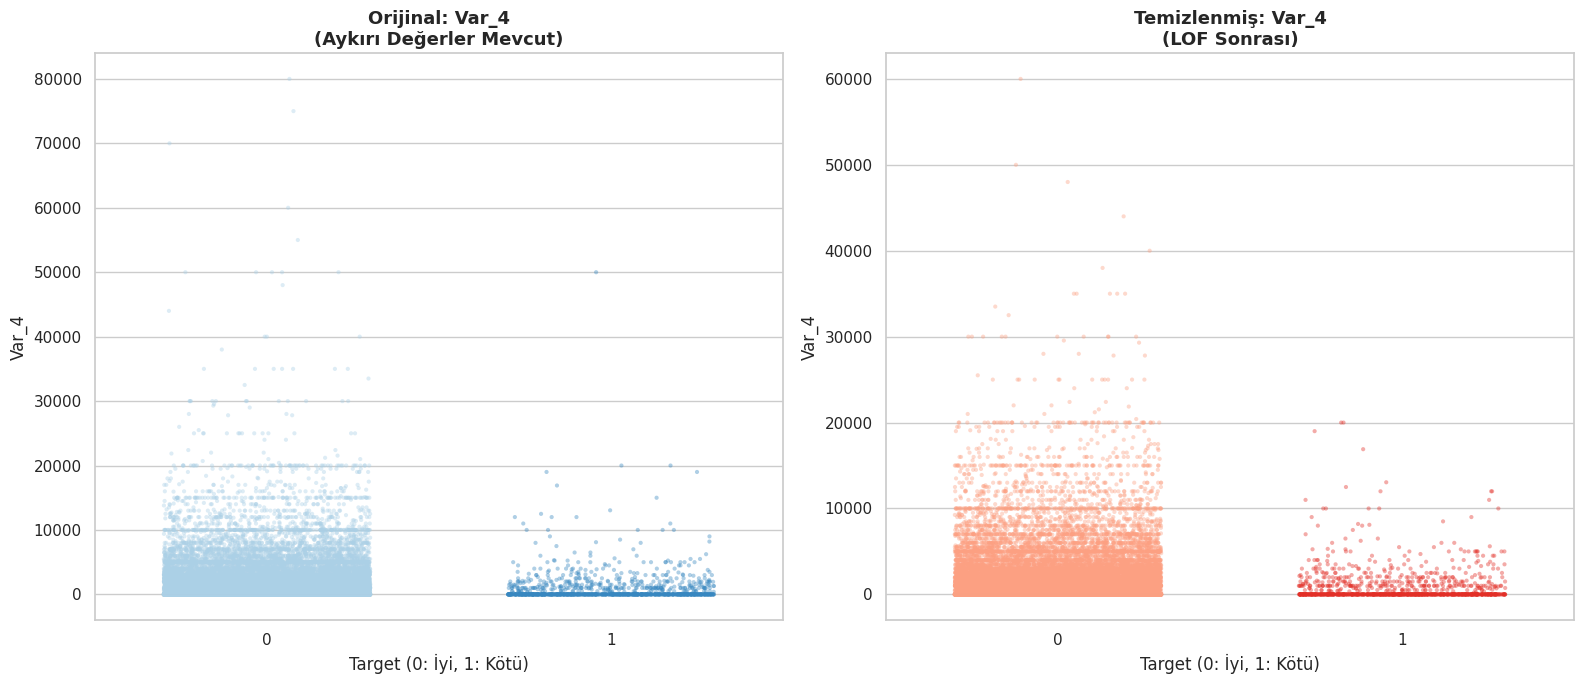

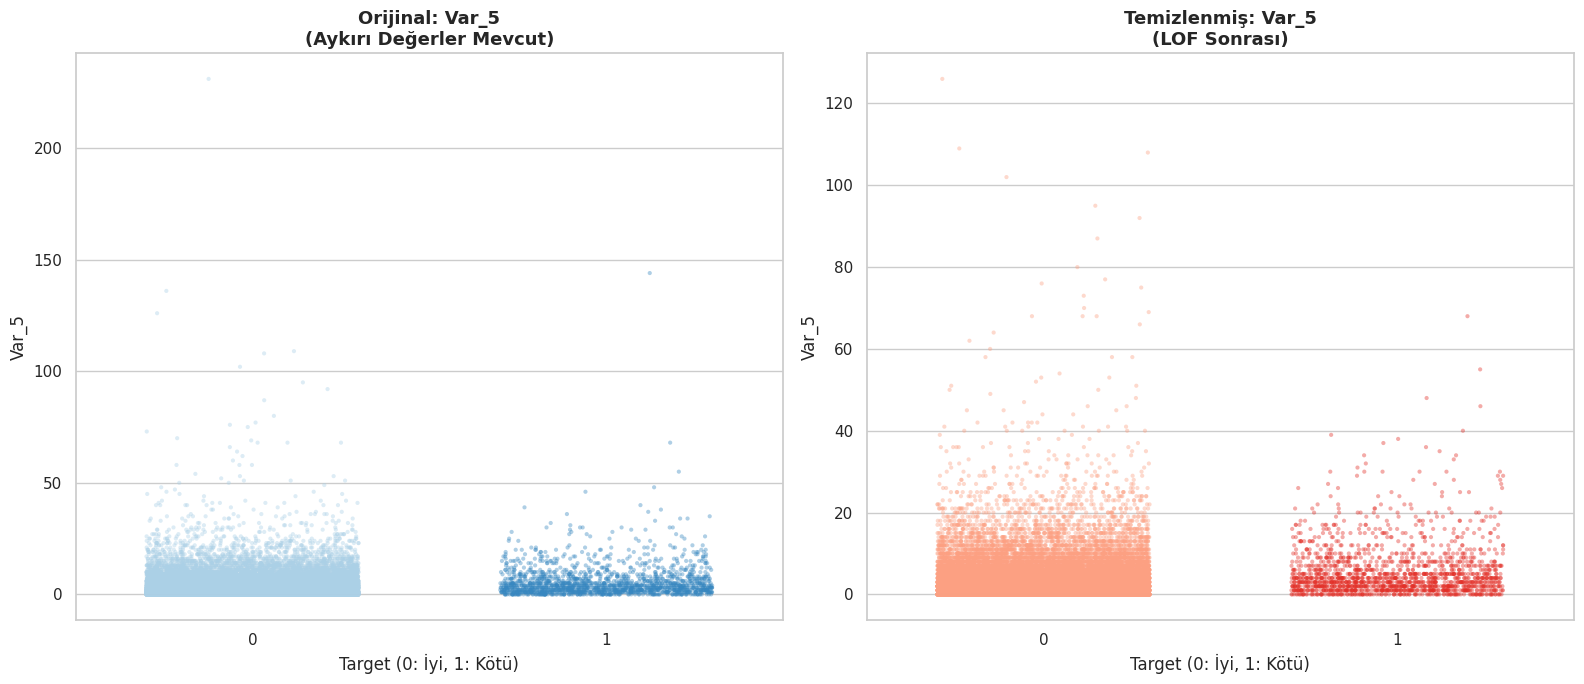

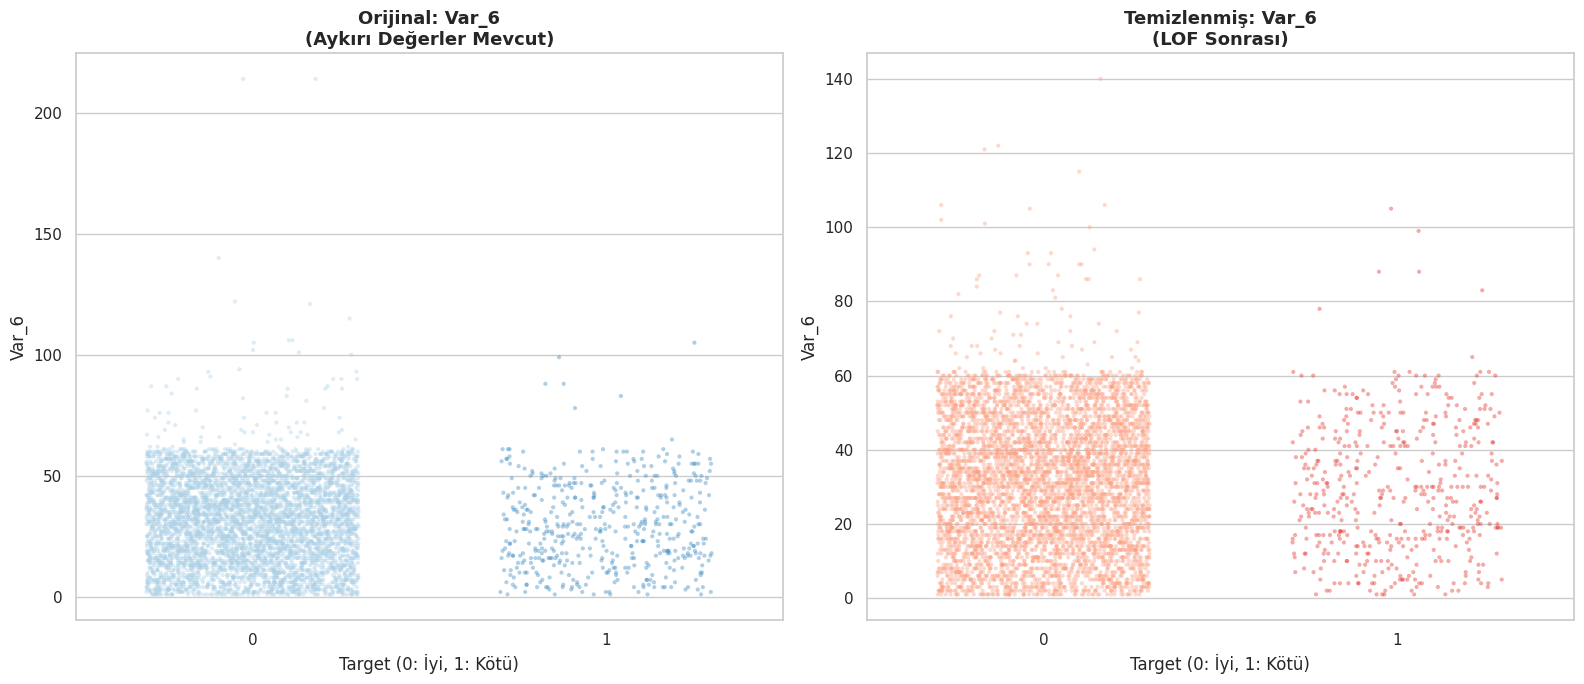

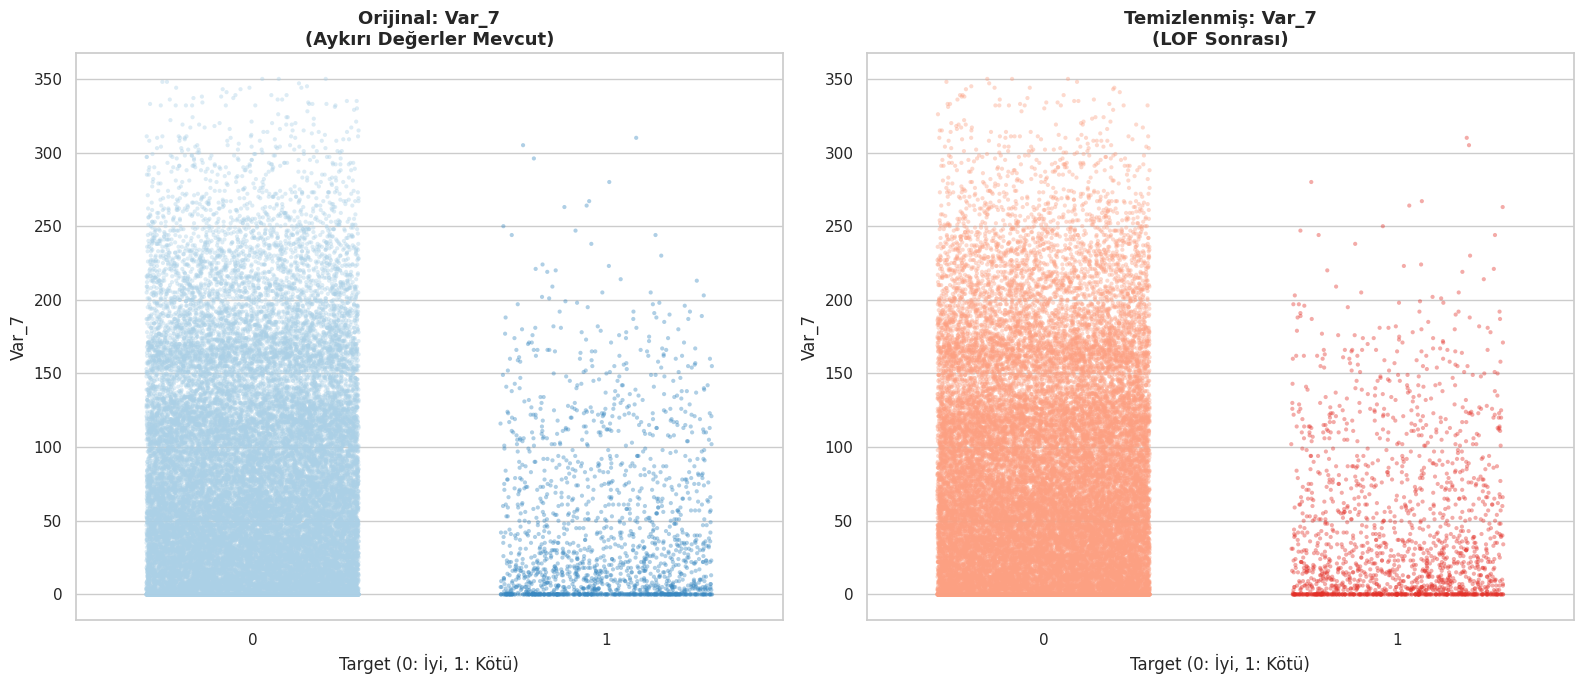

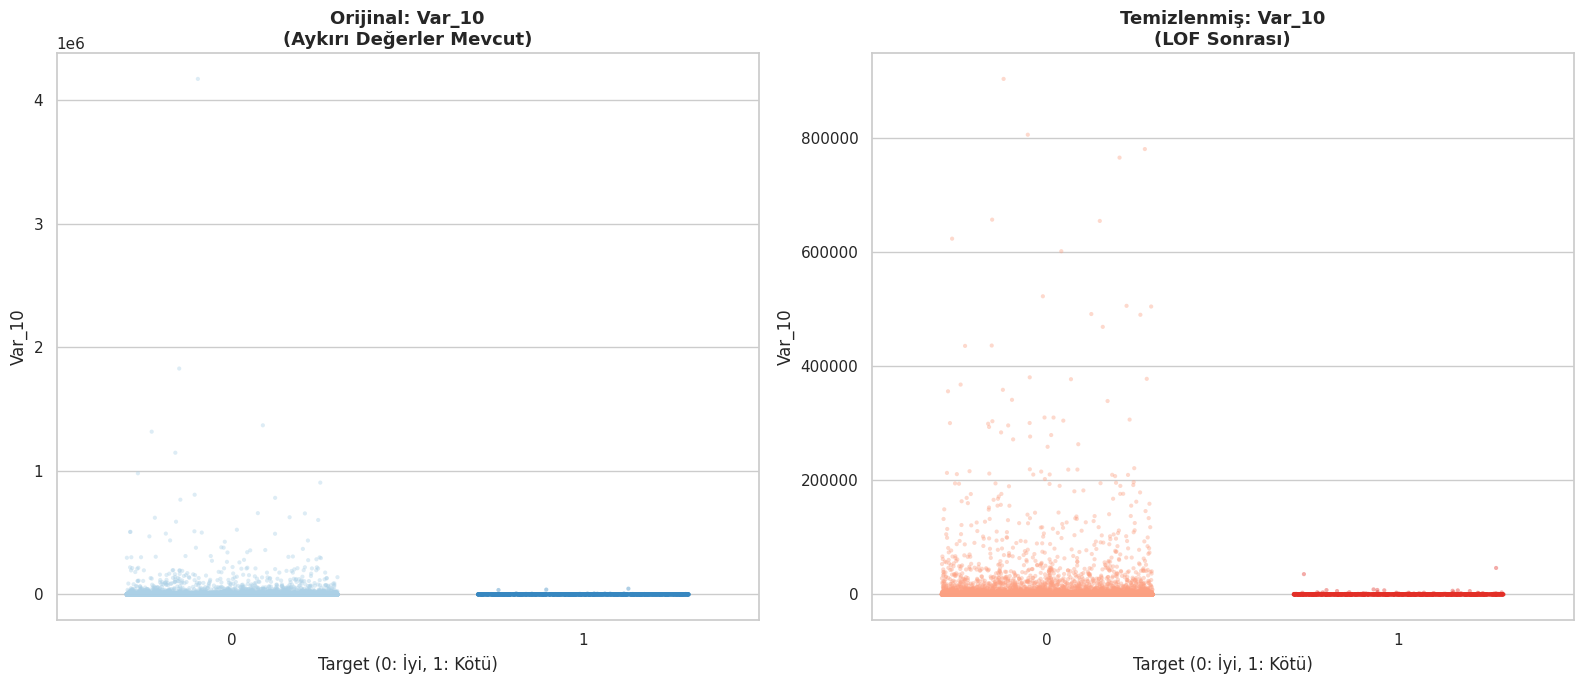

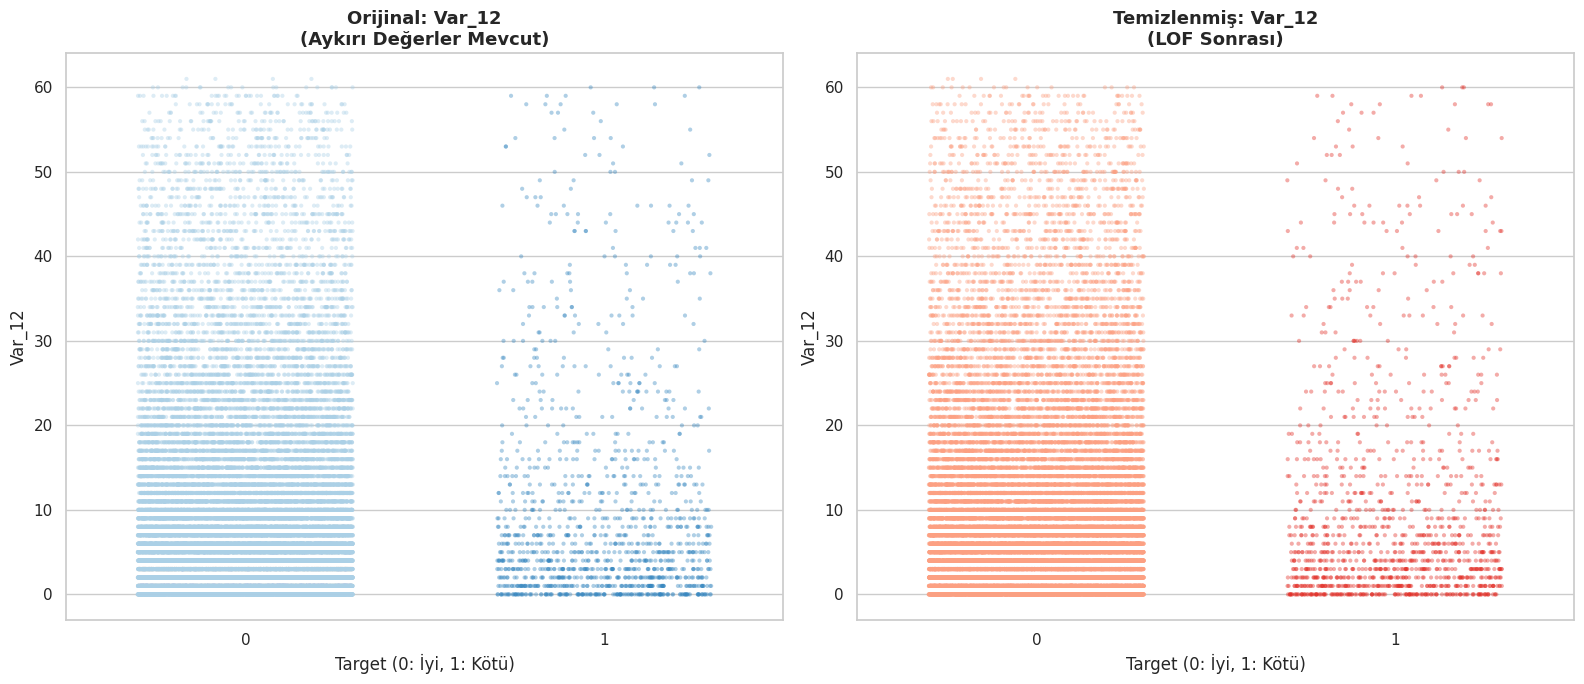

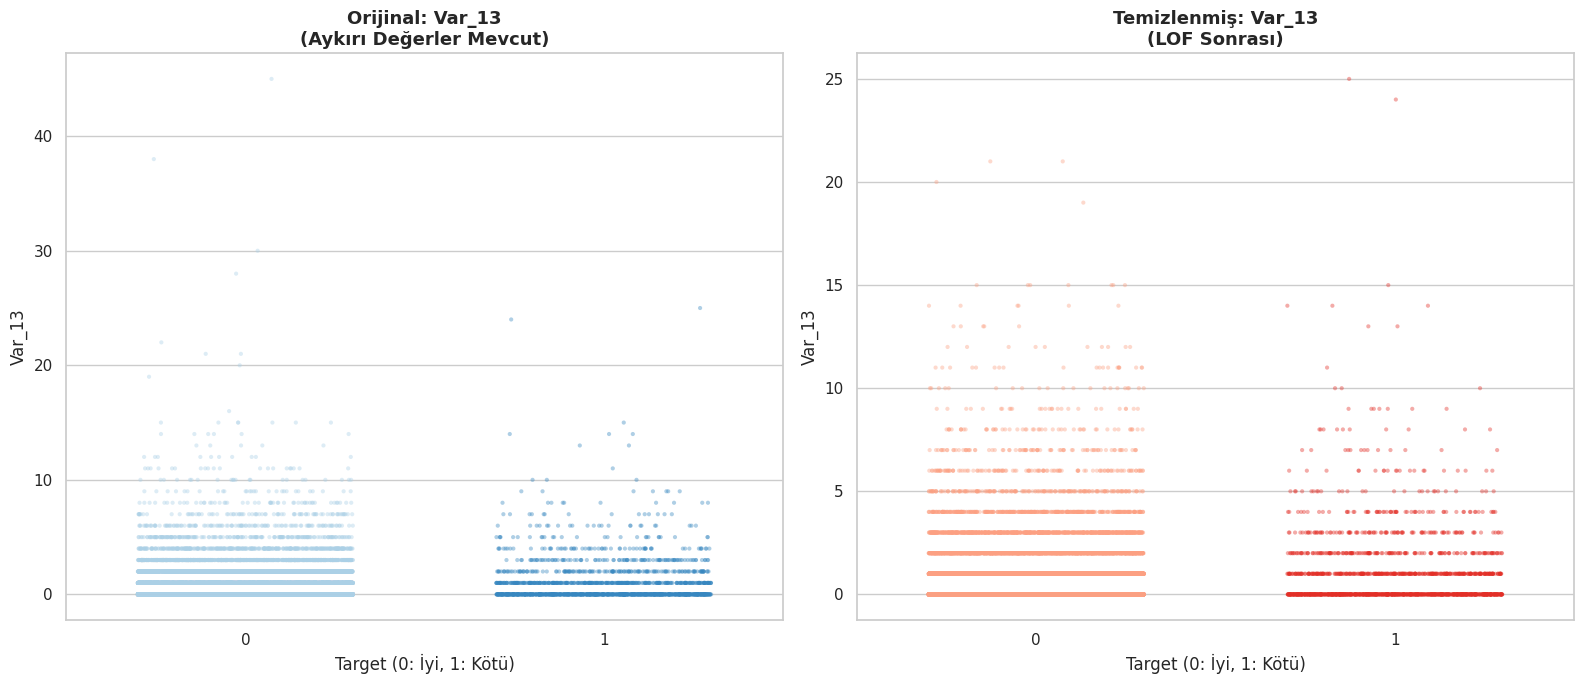

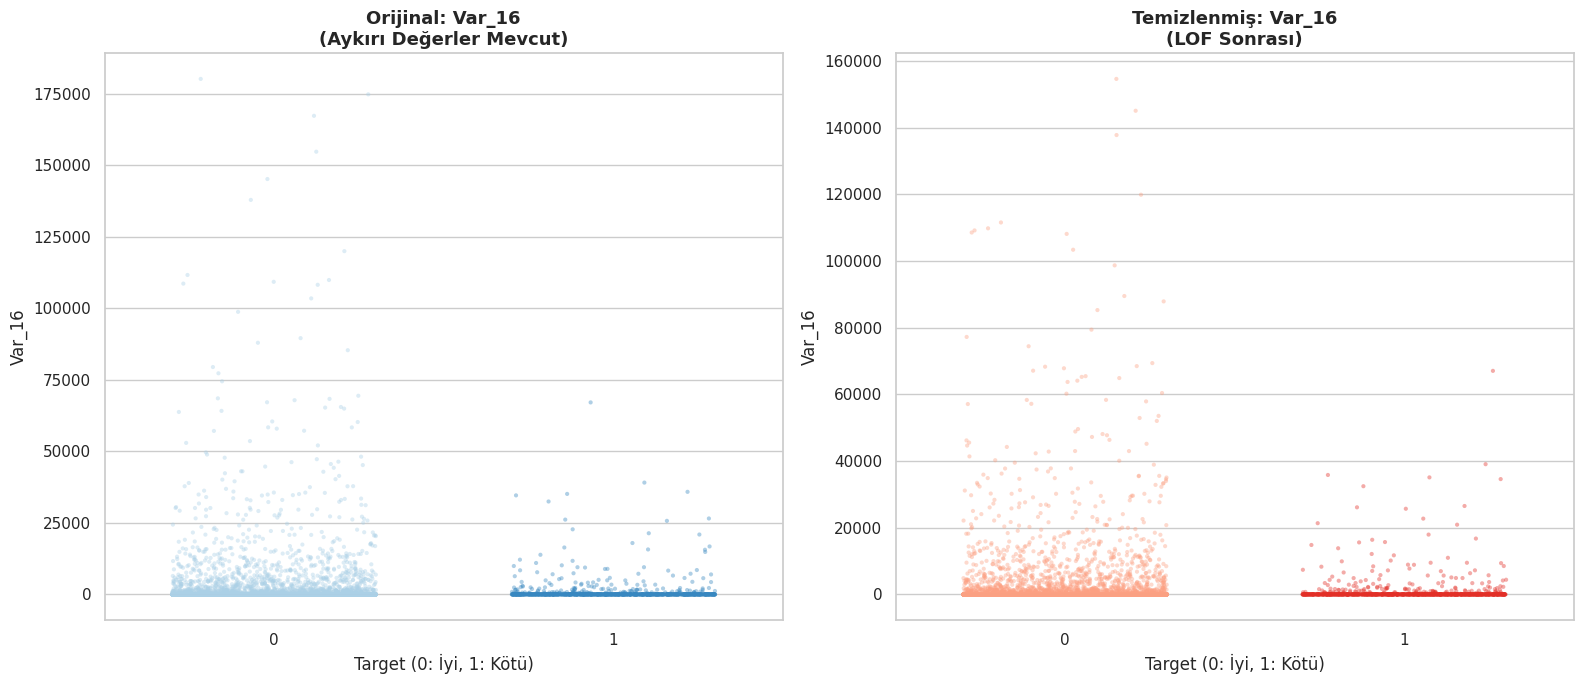

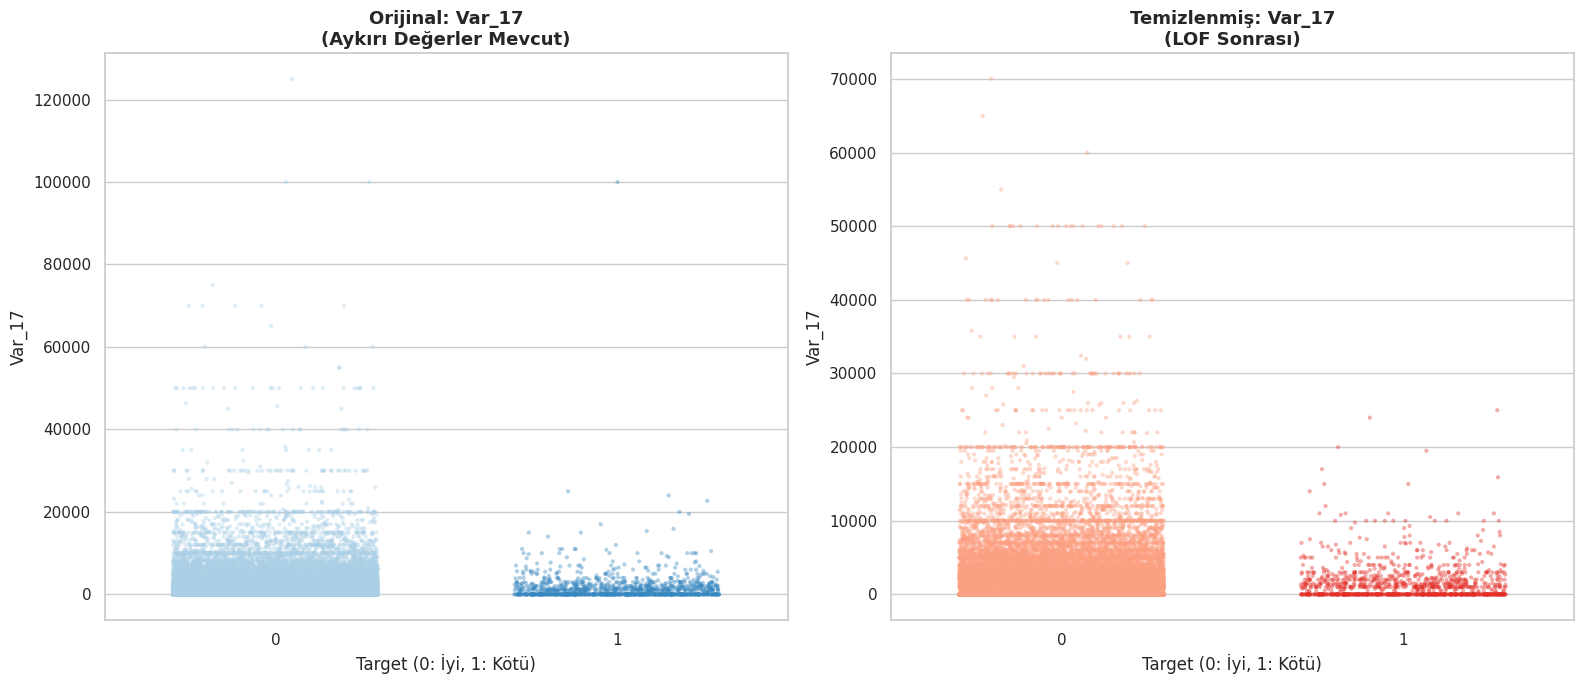

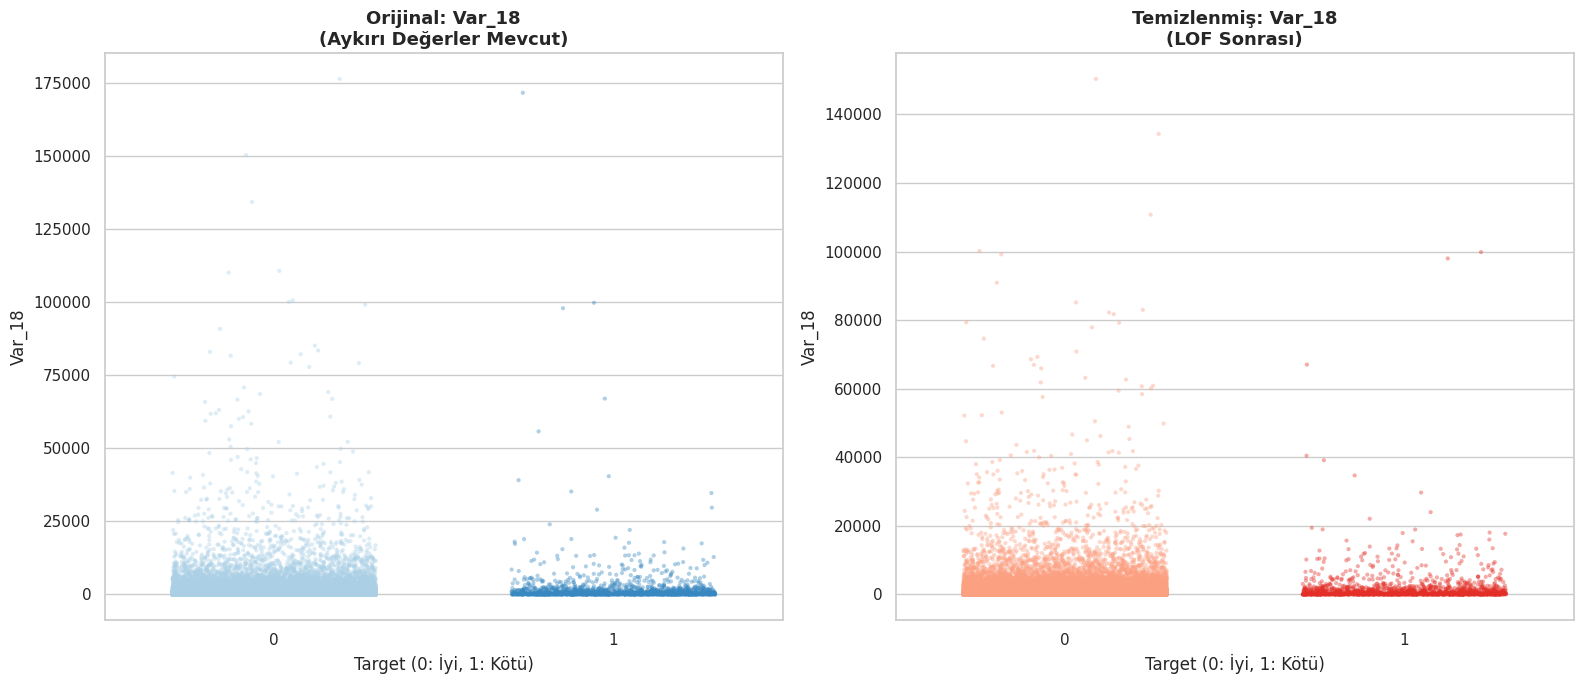

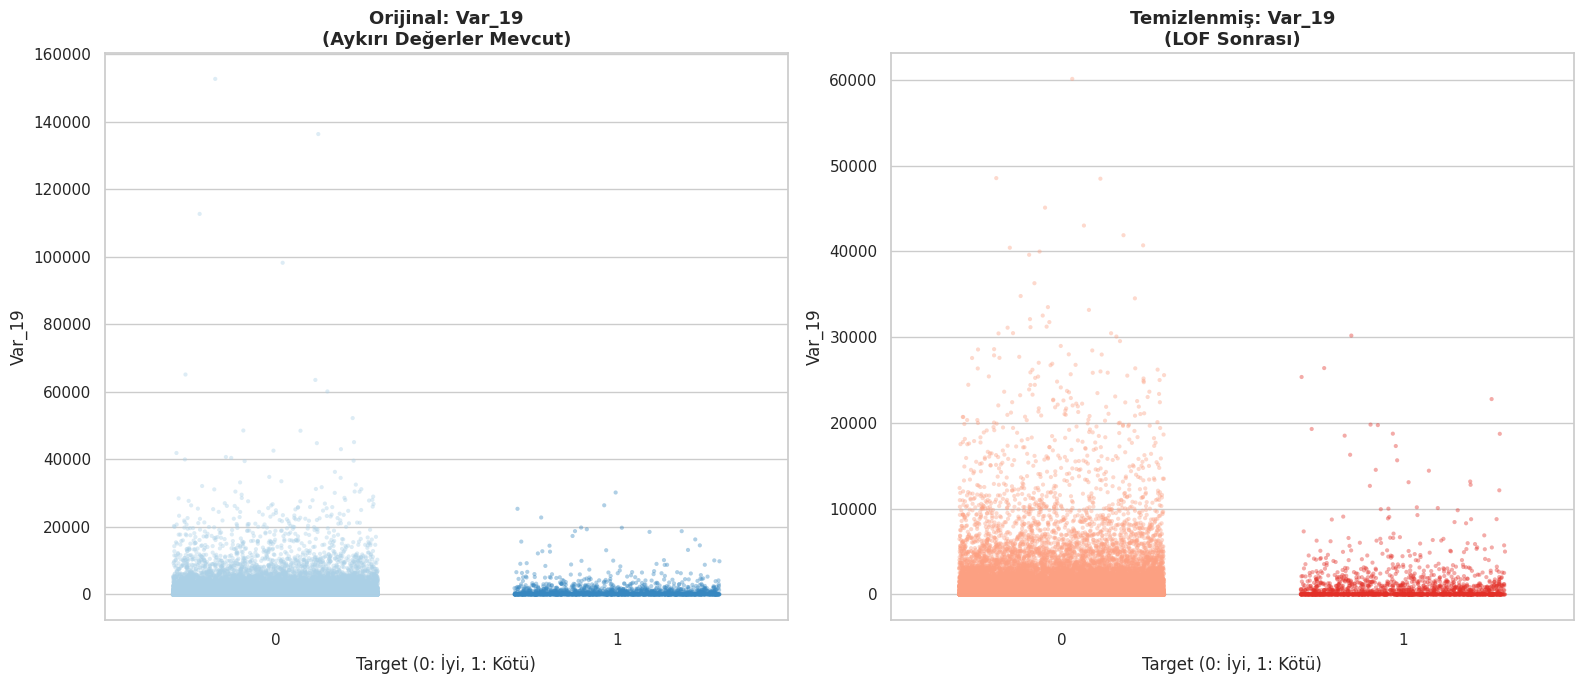

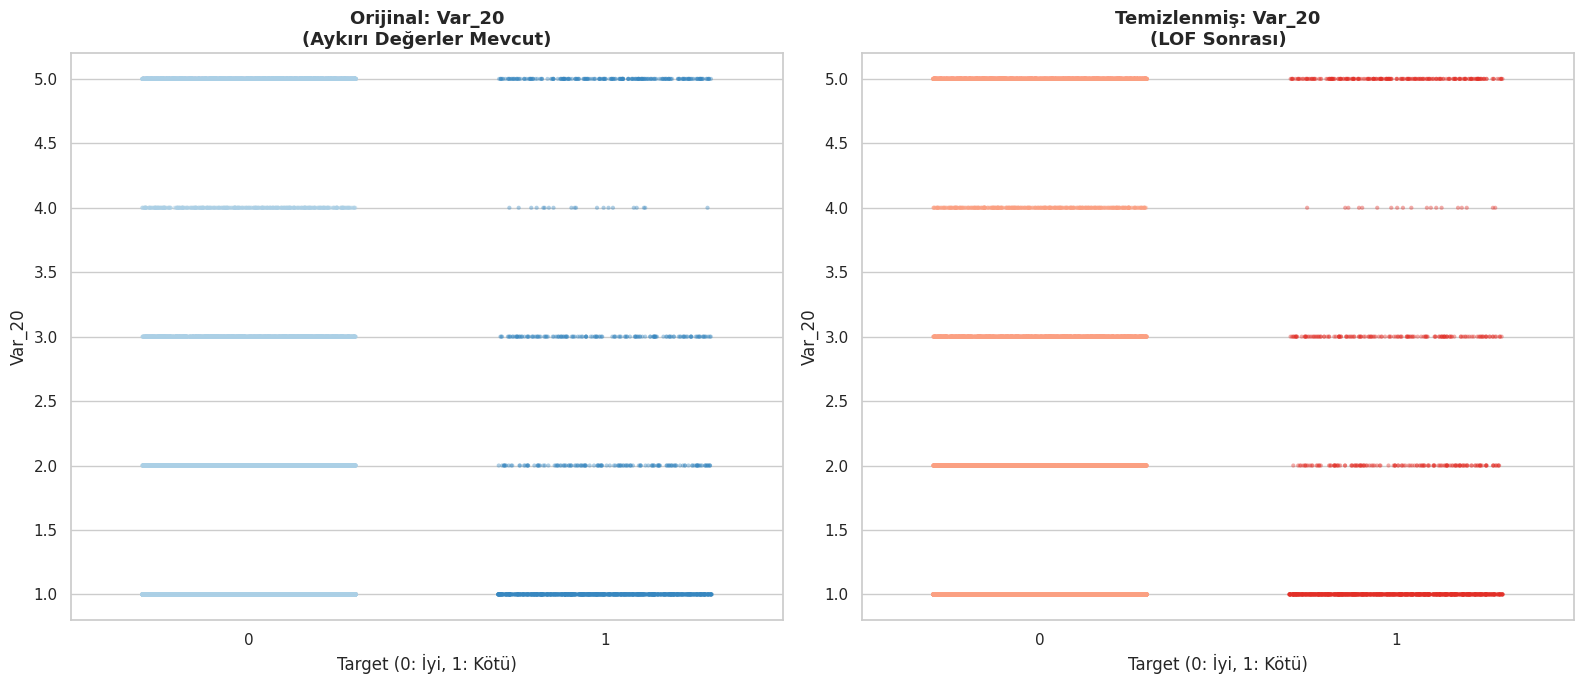

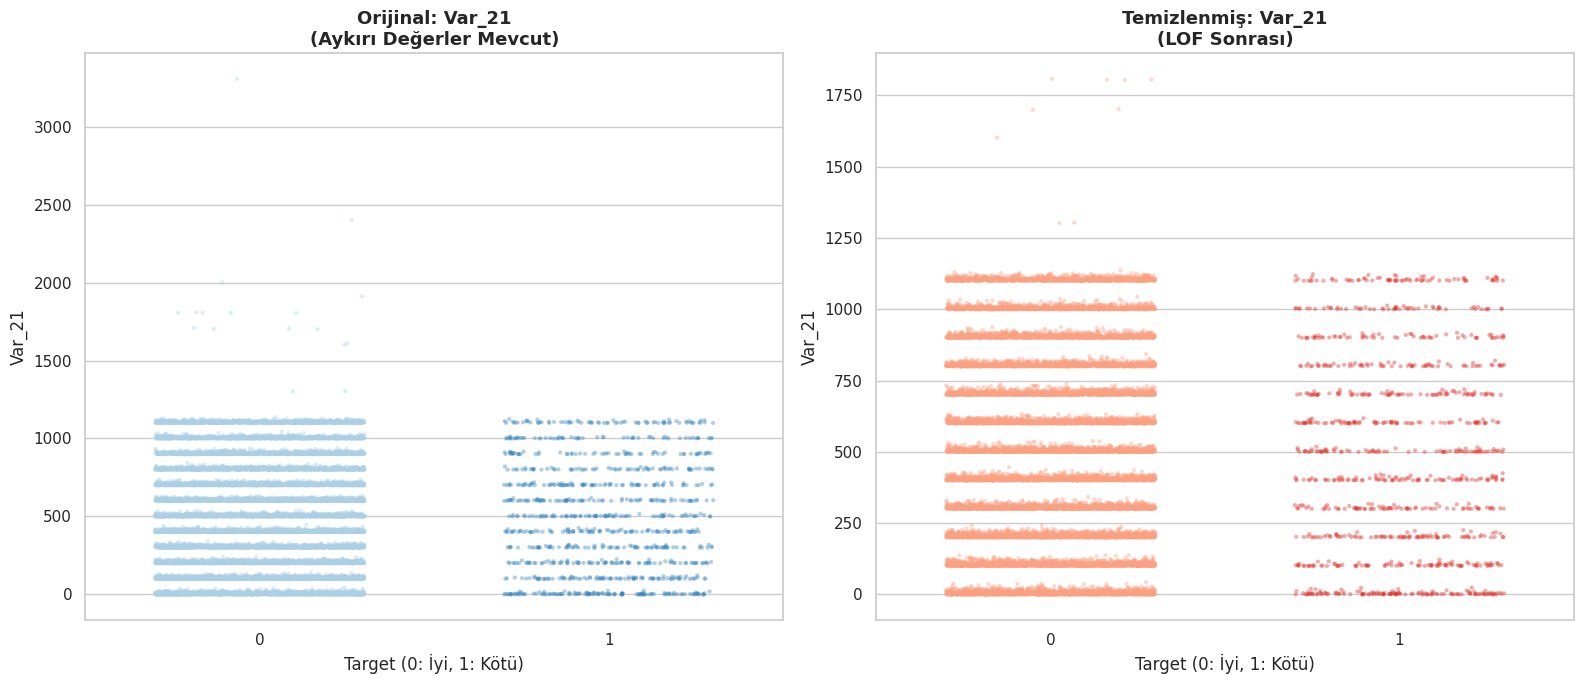

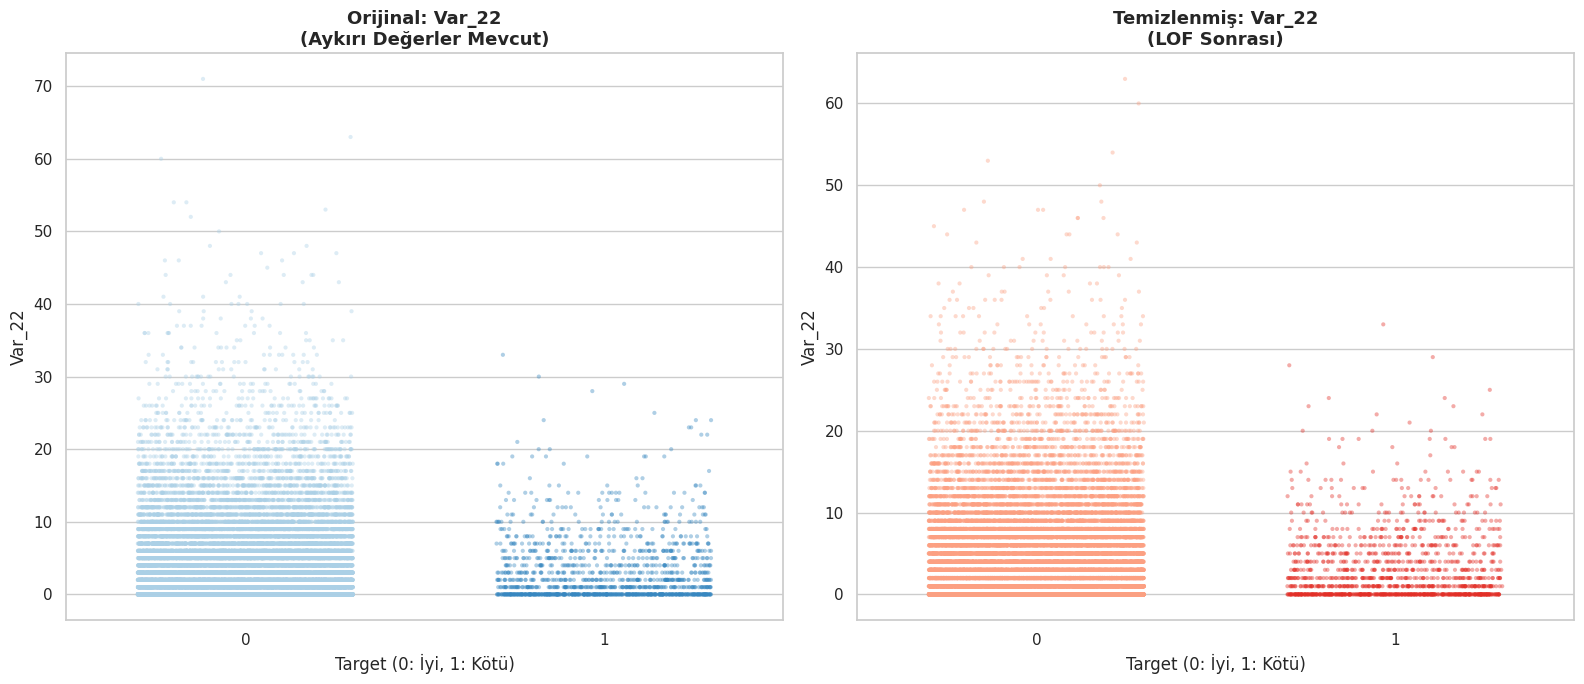

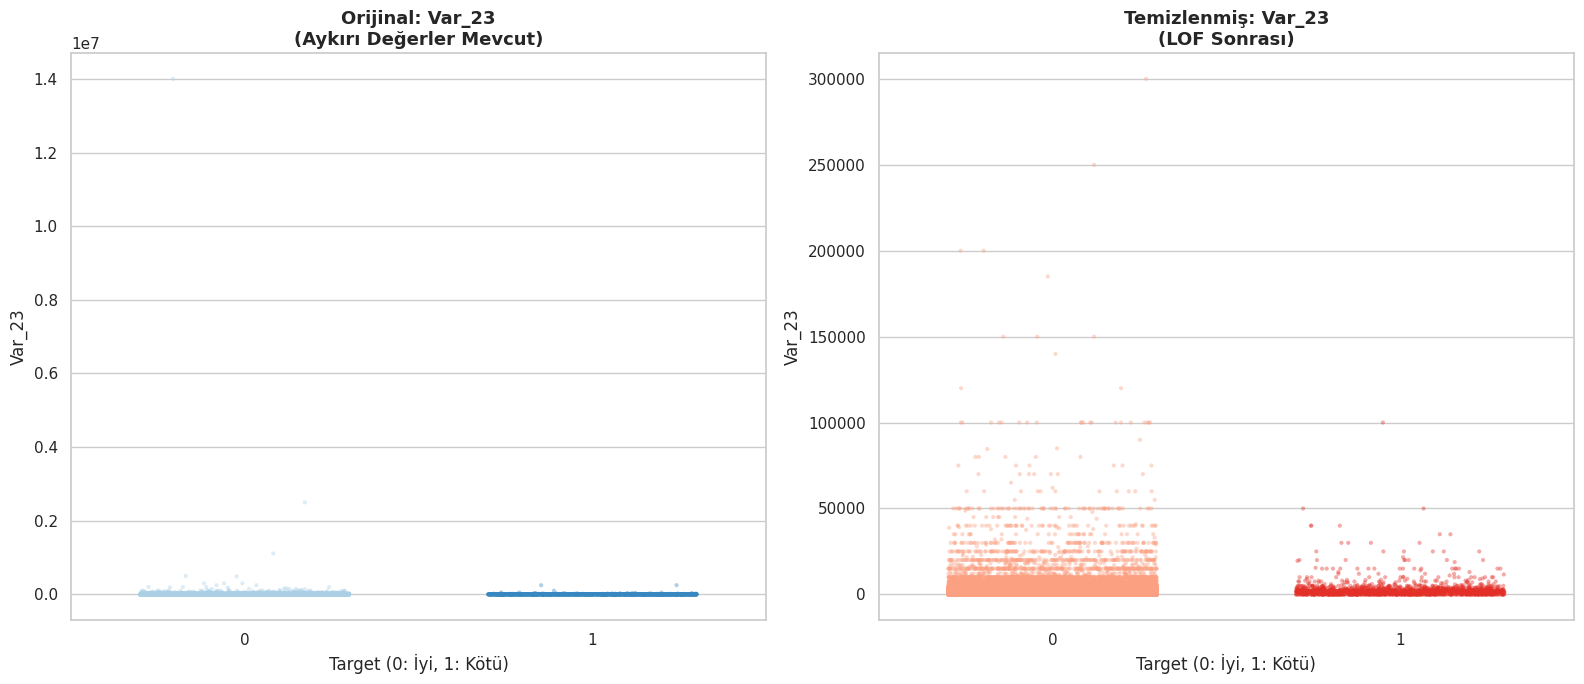

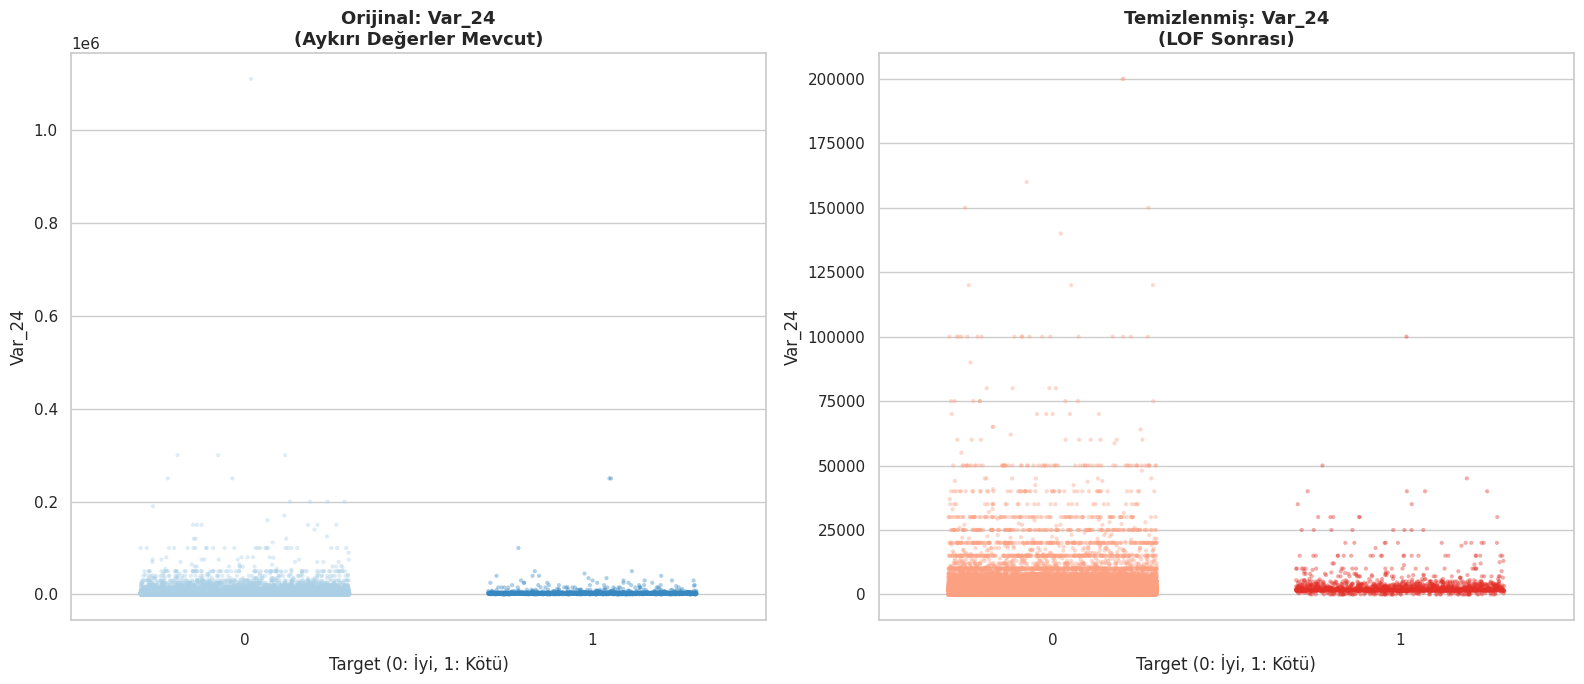

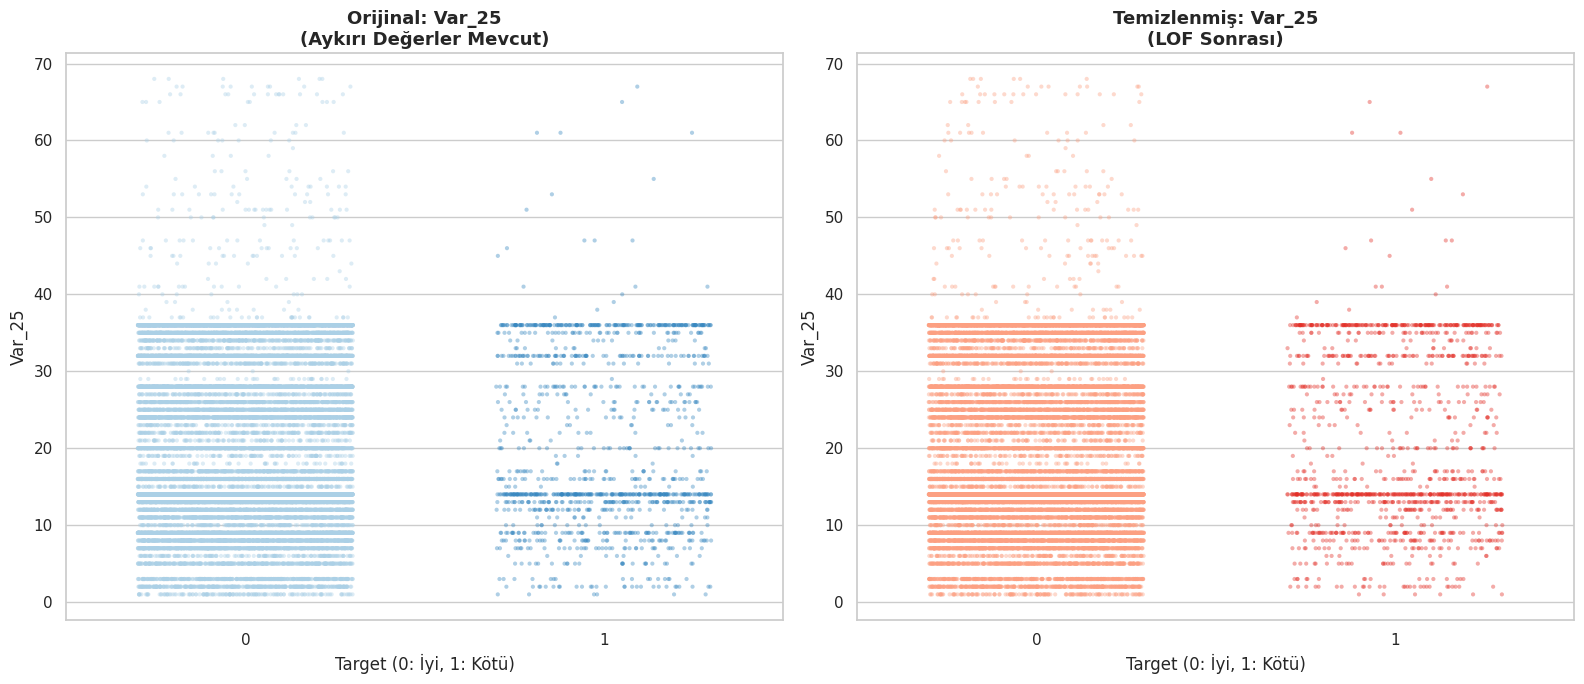

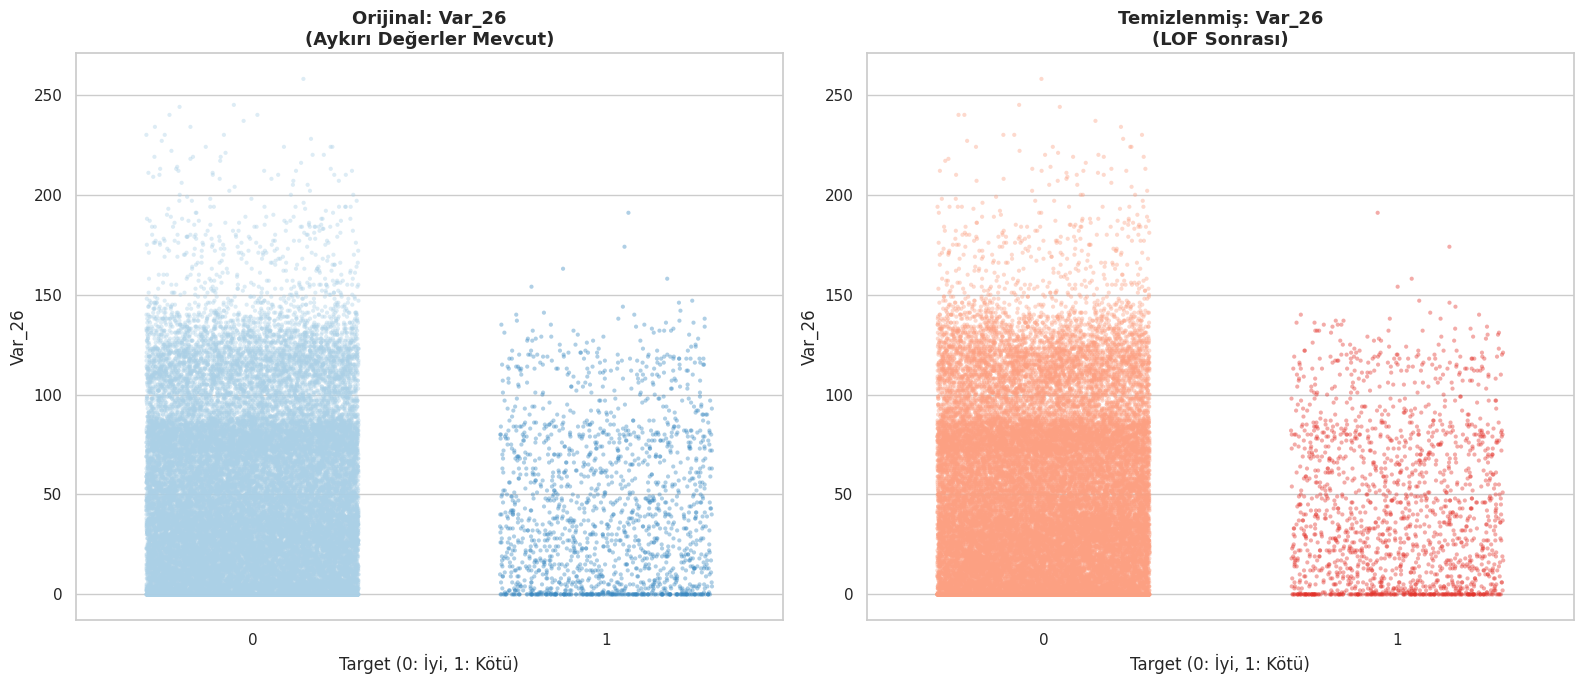

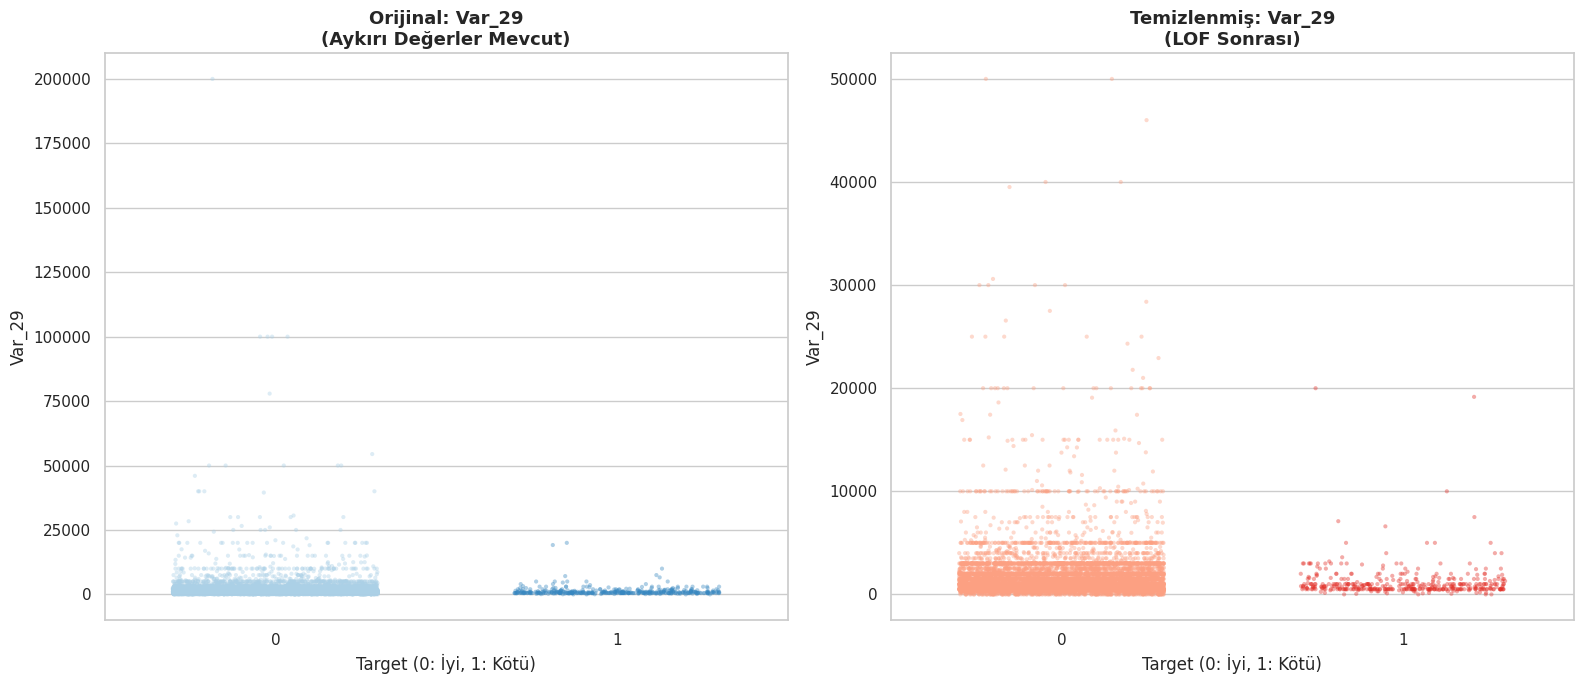

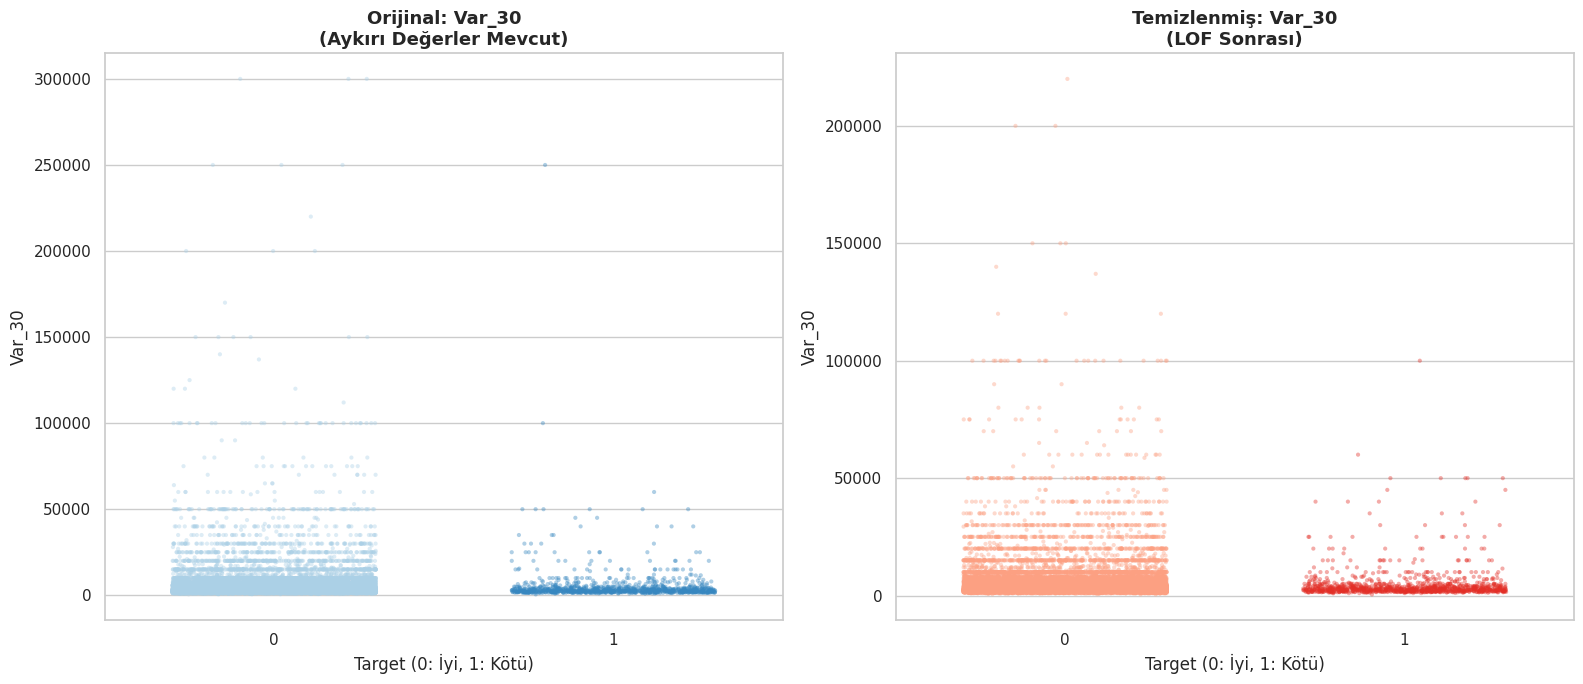

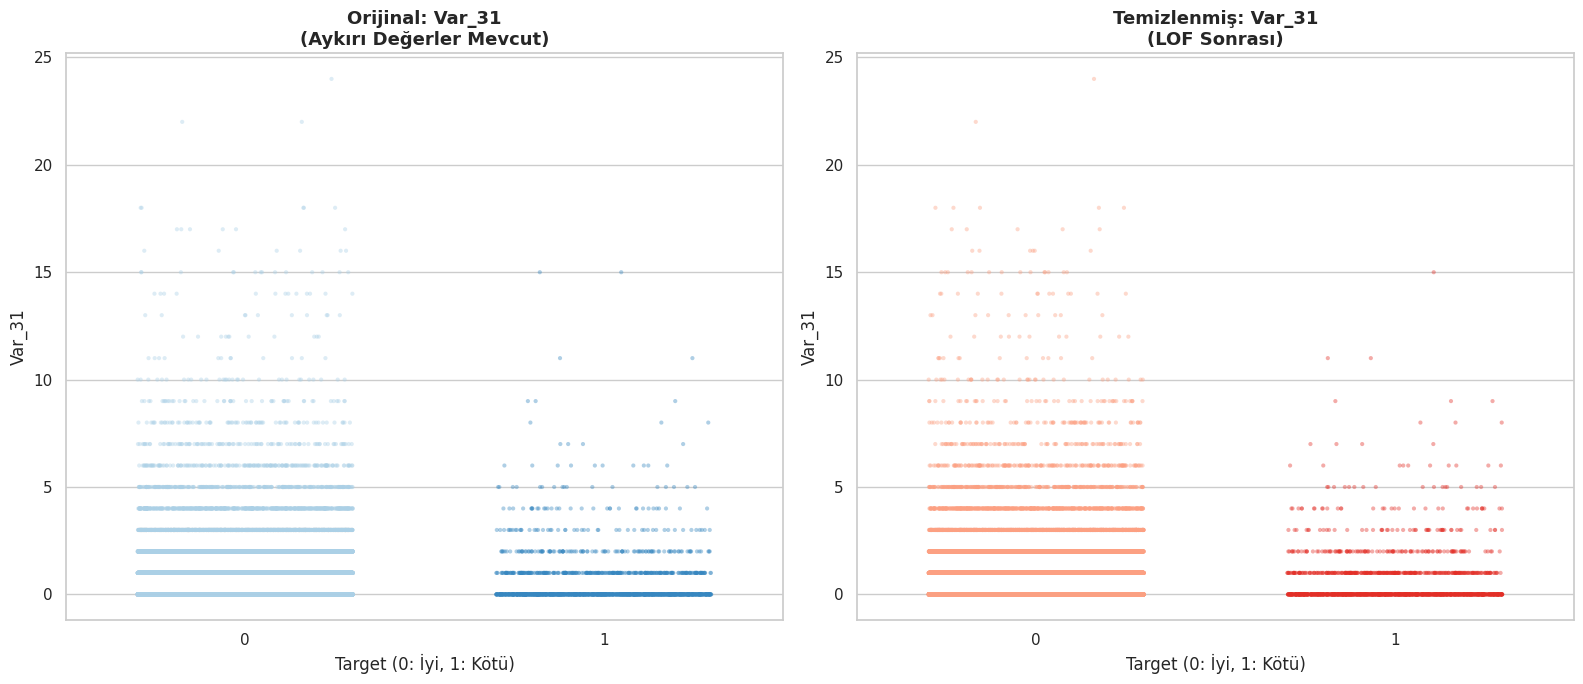

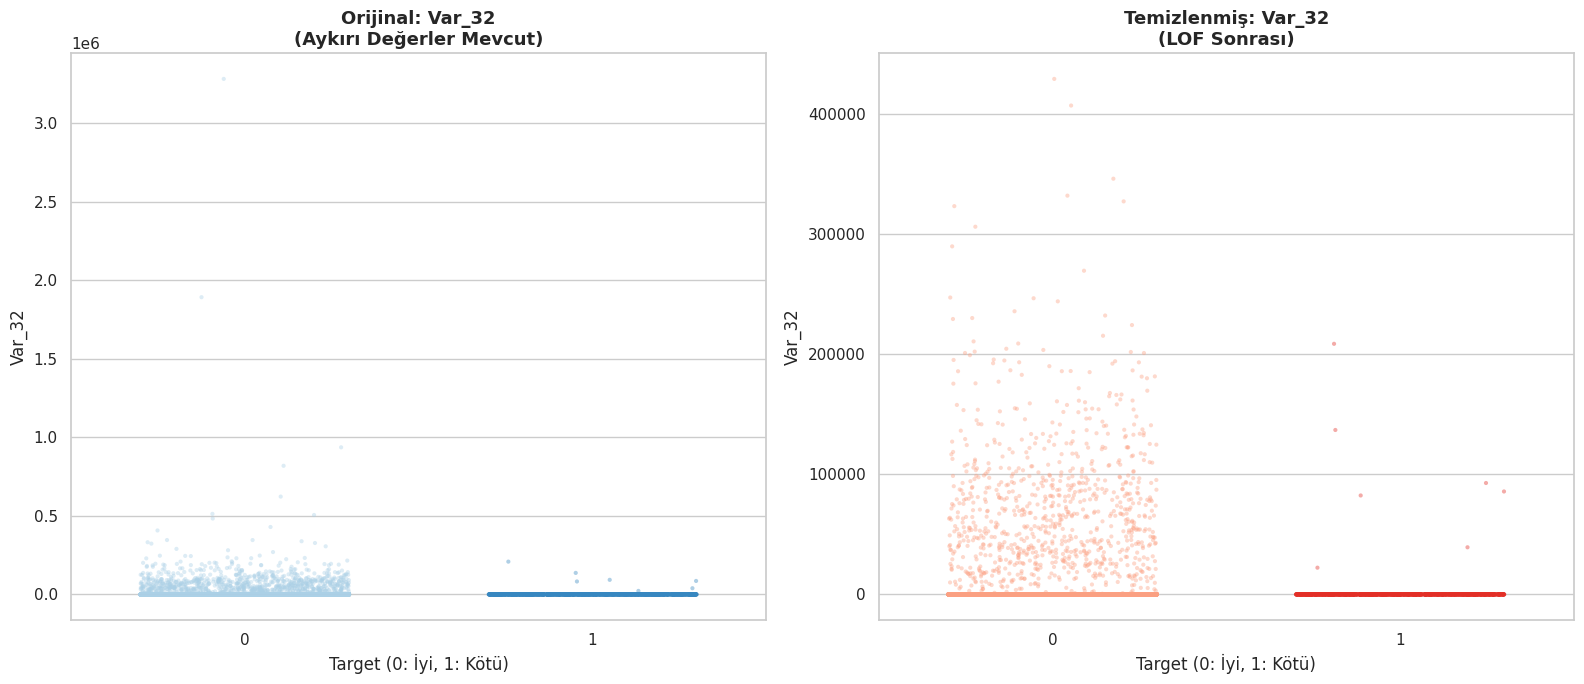

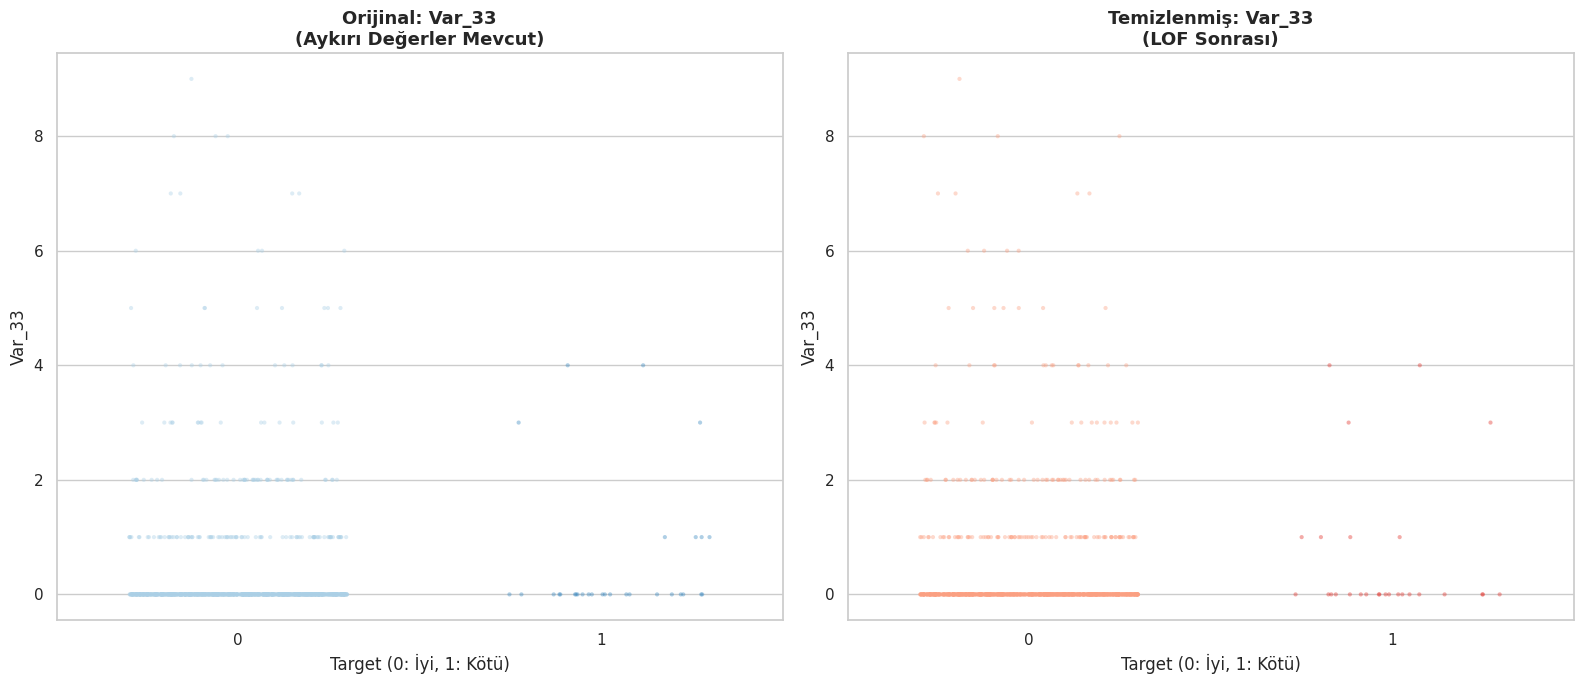

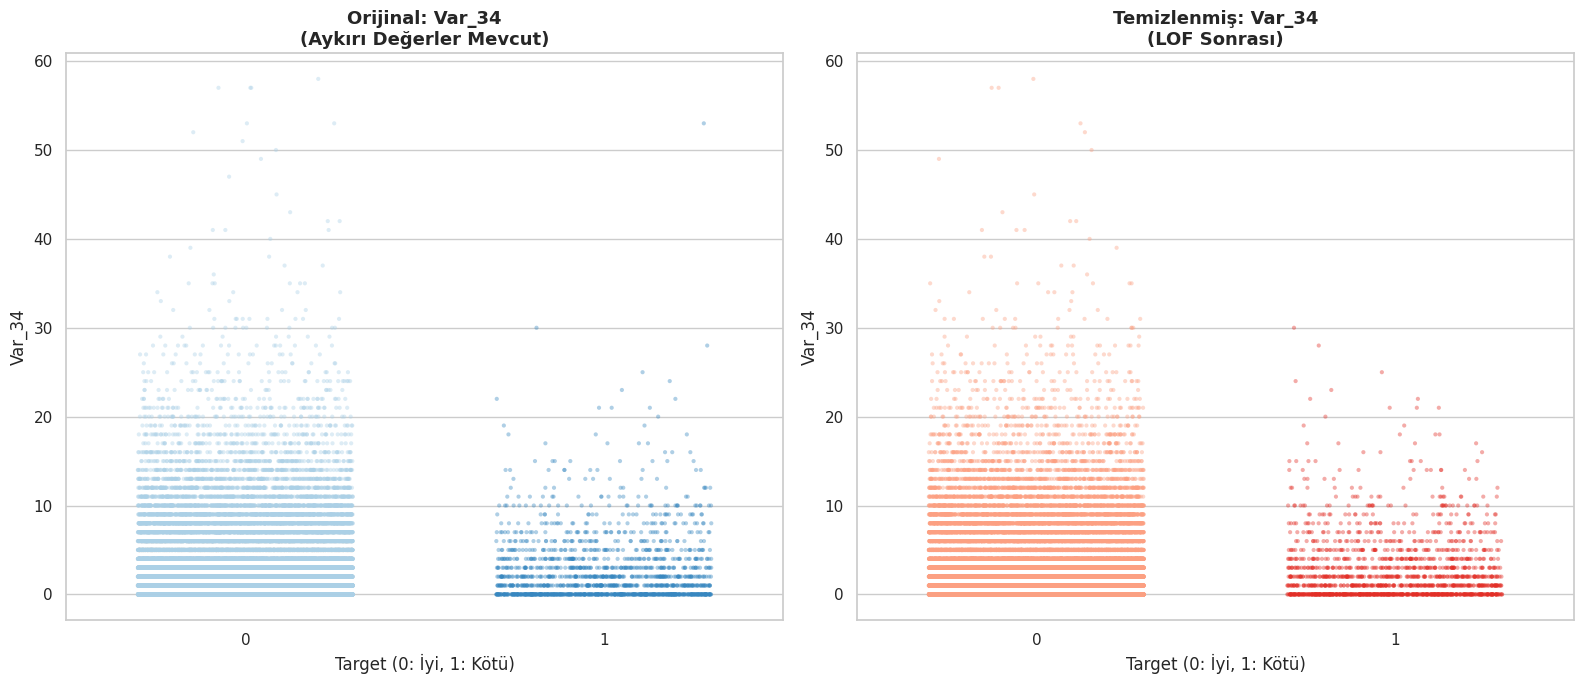

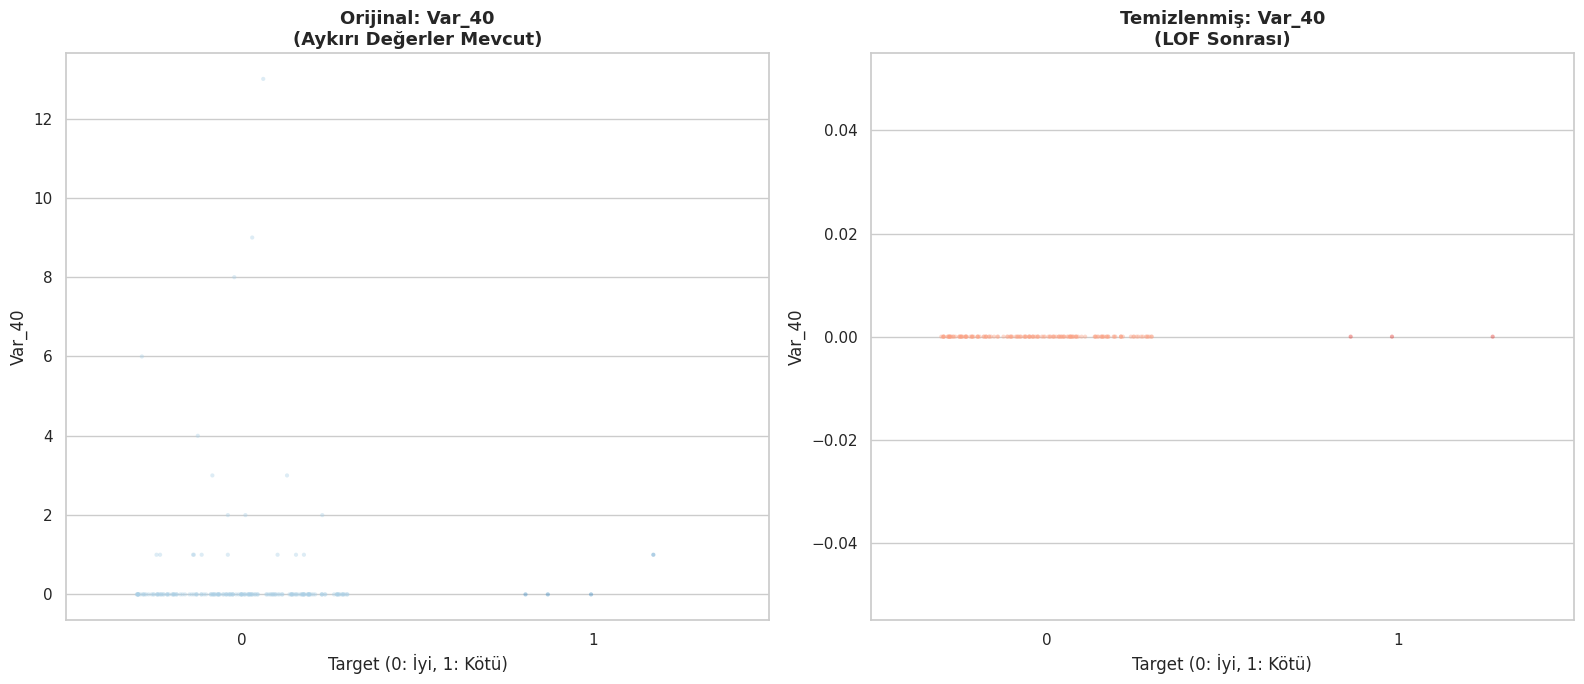

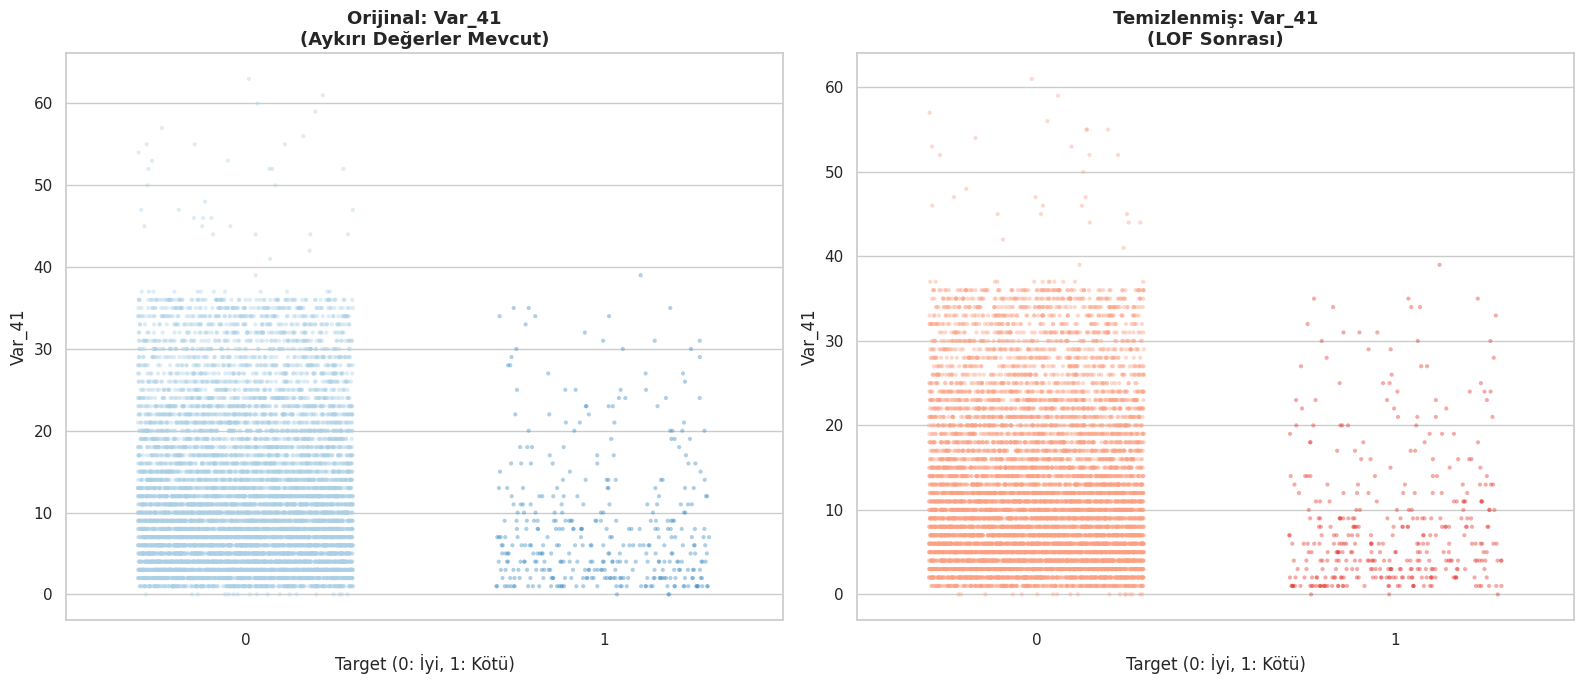

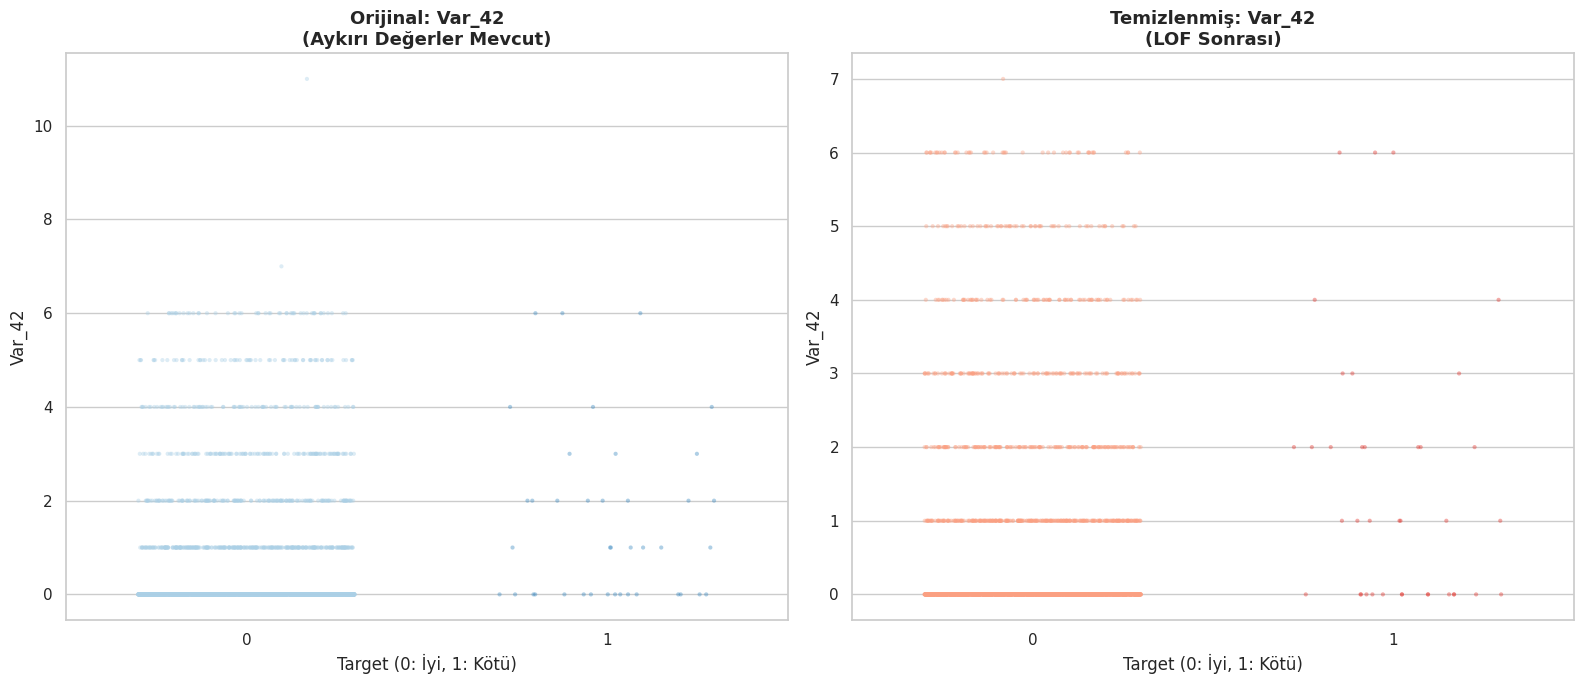

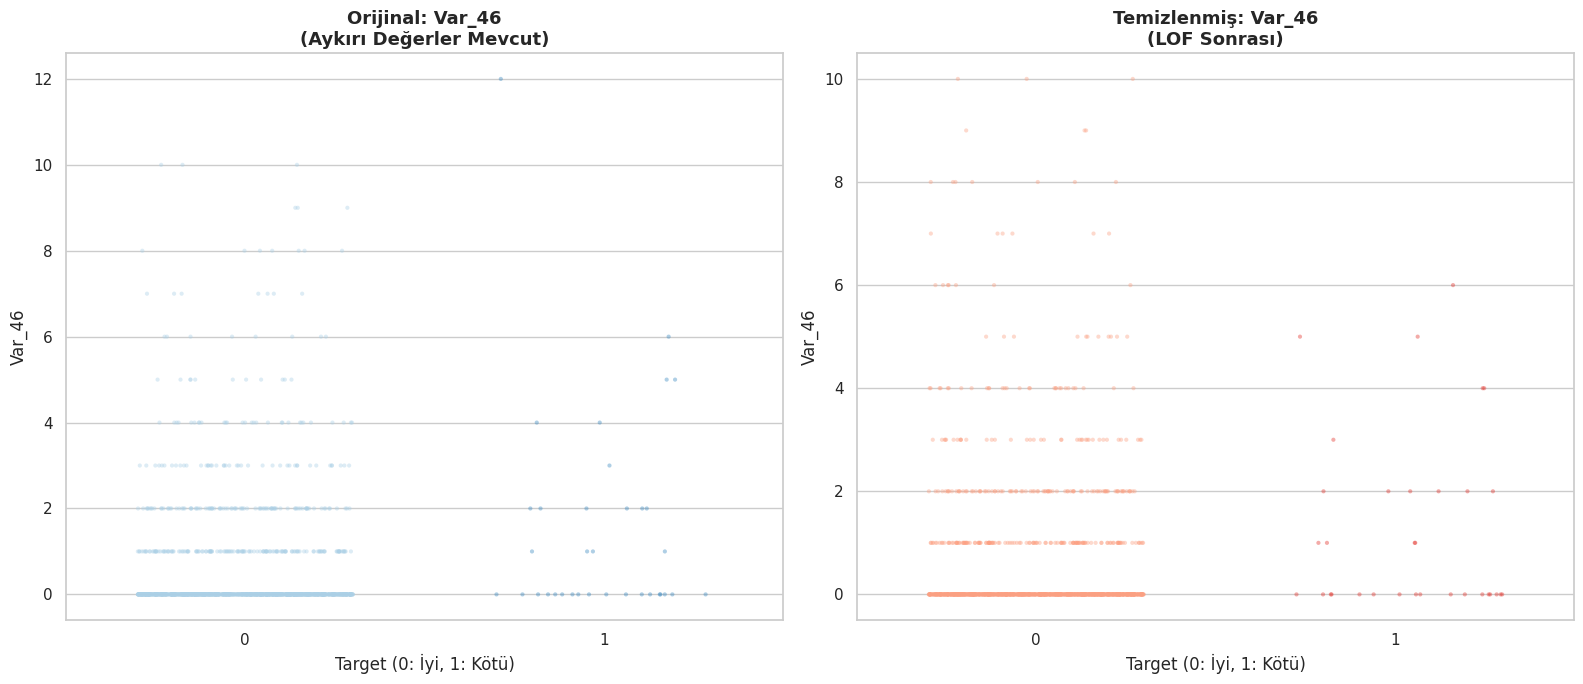

In [31]:
plot_stripplot_comparison(df, df_clean, BASE_NUMERIC_COLS, target_col=TARGET_COL)

## 5.9 Apply OHE

Elimizde kalan kategorik değişkenlere One Hot Encoding uygulayalım.

In [32]:
df = pd.get_dummies(data=df_clean,
               columns=BASE_CAT_COLS,
               drop_first=True,
               dtype=int)

In [33]:
# veriyi kaydedelim
df.to_csv("data/processed/processed.csv", index=False)